# Epsilon_study_2 — deep analysis

Probes the **algorithm internals** that the main `analysis.ipynb` does not cover:

| Section | Question |
|---------|----------|
| A | Does ε actually capture ~99.7 % of true triplet angles? |
| B | Is σ_empirical = std(true angles) consistent with σ_predicted = ε/3? |
| C | How does the solver's true/false score separation degrade with noise? |
| D | How does ε widening make matrix A denser, and when does the quantum circuit become intractable? |
| E | Is τ = 0.35 near-optimal across the noise range? |
| F | Does the Hamiltonian solve add value beyond a plain angular cut? |
| G | How do solve times scale with T, and when does statevector simulation become infeasible? |

All analyses are driven from **existing raw pickles** — no new HTCondor jobs needed.

In [1]:
import pickle, glob, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import scipy.stats as stats
import seaborn as sns
from pathlib import Path

HERE = Path('.').resolve()
FIGBASE = HERE / 'figures' / 'deep_analysis'
FIGBASE.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

In [2]:
# ── Reused helpers (verbatim from analysis.ipynb) ───────────────────────────

def controls_caption(swept: str, extra: str | None = None) -> str:
    fixed = (r"Controls: $\gamma$=3, $\delta$=1, $\phi_{\max}$=$\theta_{\max}$=0.2 rad, "
             r"$\theta_{\min}$=1.5e-5, $\tau$=0.35, $\varepsilon$=calc.(s=3), "
             r"conv OFF, hit-ineff 0, 5 planes $\Delta z$=33 mm, statevector 1BQF")
    parts = [fixed]
    if extra:
        parts.append("Fixed here: " + extra)
    parts.append("Swept: " + swept)
    return "\n".join(parts)


def _auc(scores, truth):
    """ROC-AUC via rank-based Mann-Whitney U (ties = 0.5). No sklearn needed."""
    scores = np.asarray(scores, float)
    truth  = np.asarray(truth, bool)
    n_t, n_f = int(truth.sum()), int((~truth).sum())
    if n_t == 0 or n_f == 0 or not np.isfinite(scores).all():
        return np.nan
    order = np.argsort(scores, kind='mergesort')
    s_sort = scores[order]
    ranks_sorted = np.empty(len(scores), float)
    i, N = 0, len(scores)
    while i < N:
        j = i
        while j + 1 < N and s_sort[j + 1] == s_sort[i]:
            j += 1
        ranks_sorted[i:j + 1] = (i + j) / 2.0 + 1.0
        i = j + 1
    ranks = np.empty(N, float)
    ranks[order] = ranks_sorted
    sum_ranks_true = ranks[truth].sum()
    return (sum_ranks_true - n_t * (n_t + 1) / 2.0) / (n_t * n_f)

In [3]:
# ── Load ALL pickles, keeping full array data ────────────────────────────────

def load_all_records(results_root: Path) -> list[dict]:
    """Load every ok-status pickle; returns list of dicts with arrays intact."""
    records = []
    for fp in sorted(results_root.rglob('*.pkl')):
        try:
            r = pickle.load(open(fp, 'rb'))
        except Exception:
            continue
        if r.get('status') == 'ok':
            records.append(r)
    return records

records = load_all_records(HERE / 'results')

SCALAR_KEYS = [
    'n_trk', 'rep', 'sigma_res', 'sigma_scatt', 'epsilon',
    'n_seg', 'A_nnz', 'n_qubits', 'n_pad', 'cos_QC',
    't_gen', 't_angles', 't_classical', 't_q',
]

df = pd.DataFrame([
    {k: r.get(k) for k in SCALAR_KEYS} for r in records
]).dropna(subset=['n_trk'])
df = df.astype({'n_trk': int, 'rep': int})

# Only sensitivity records (not validation, not seg14e) for noise-grid analyses
sens_mask = [str(r.get('tag', '')).startswith('eps2_sr') for r in records]
sens_records = [r for r, m in zip(records, sens_mask) if m]
sens_df = df[sens_mask].copy()

print(f"Total records: {len(records)}  |  Sensitivity: {len(sens_records)}")
print(f"T values present: {sorted(sens_df.n_trk.unique())}")
print(f"σ_res values: {sorted(sens_df.sigma_res.unique())}")
print(f"σ_scatt values: {sorted(sens_df.sigma_scatt.unique())}")

Total records: 1048  |  Sensitivity: 468
T values present: [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
σ_res values: [np.float64(0.0), np.float64(0.01), np.float64(0.02), np.float64(0.05)]
σ_scatt values: [np.float64(0.0001), np.float64(0.0003), np.float64(0.0005)]


---
## Section A — ε formula validation

The formula predicts that ε captures ~99.7 % of true triplet kink angles
(3σ coverage).  We check this directly against the stored `true_angles` arrays
and show where the Gaussian / linearisation assumptions break down.

In [4]:
# Pool true_angles and false_angles per (sigma_res, sigma_scatt) at T=50
T_REF = 50
sr_vals   = sorted(sens_df.sigma_res.unique())
ss_vals   = sorted(sens_df.sigma_scatt.unique())

angle_cells = {}
for r in sens_records:
    if int(r['n_trk']) != T_REF:
        continue
    key = (float(r['sigma_res']), float(r['sigma_scatt']))
    if key not in angle_cells:
        angle_cells[key] = dict(true=[], false=[], epsilon=float(r['epsilon']))
    ta = r.get('true_angles')
    fa = r.get('false_angles')
    if ta is not None: angle_cells[key]['true'].extend(np.asarray(ta).ravel())
    if fa is not None: angle_cells[key]['false'].extend(np.asarray(fa).ravel())

# Convert to arrays and compute empirical coverage
for key in angle_cells:
    d = angle_cells[key]
    d['true']  = np.asarray(d['true'],  float)
    d['false'] = np.asarray(d['false'], float)
    eps = d['epsilon']
    ta  = d['true']
    d['coverage'] = float((ta <= eps).sum() / len(ta)) if len(ta) else np.nan

print(f"Grid cells at T={T_REF}: {len(angle_cells)}")
for (sr, ss), d in sorted(angle_cells.items()):
    print(f"  σ_r={sr:.3f}  σ_s={ss:.1e}  ε={d['epsilon']:.4e}  "
          f"n_true={len(d['true'])}  coverage={d['coverage']:.3f}")

Grid cells at T=50: 12
  σ_r=0.000  σ_s=1.0e-04  ε=4.2479e-04  n_true=1500  coverage=1.000
  σ_r=0.000  σ_s=3.0e-04  ε=1.2730e-03  n_true=1500  coverage=1.000
  σ_r=0.000  σ_s=5.0e-04  ε=2.1214e-03  n_true=1500  coverage=0.999
  σ_r=0.010  σ_s=1.0e-04  ε=3.1777e-03  n_true=1500  coverage=1.000
  σ_r=0.010  σ_s=3.0e-04  ε=3.3967e-03  n_true=1500  coverage=1.000
  σ_r=0.010  σ_s=5.0e-04  ε=3.7971e-03  n_true=1500  coverage=1.000
  σ_r=0.020  σ_s=1.0e-04  ε=6.3127e-03  n_true=1500  coverage=1.000
  σ_r=0.020  σ_s=3.0e-04  ε=6.4257e-03  n_true=1500  coverage=1.000
  σ_r=0.020  σ_s=5.0e-04  ε=6.6460e-03  n_true=1500  coverage=1.000
  σ_r=0.050  σ_s=1.0e-04  ε=1.5752e-02  n_true=1500  coverage=1.000
  σ_r=0.050  σ_s=3.0e-04  ε=1.5797e-02  n_true=1500  coverage=1.000
  σ_r=0.050  σ_s=5.0e-04  ε=1.5888e-02  n_true=1500  coverage=1.000


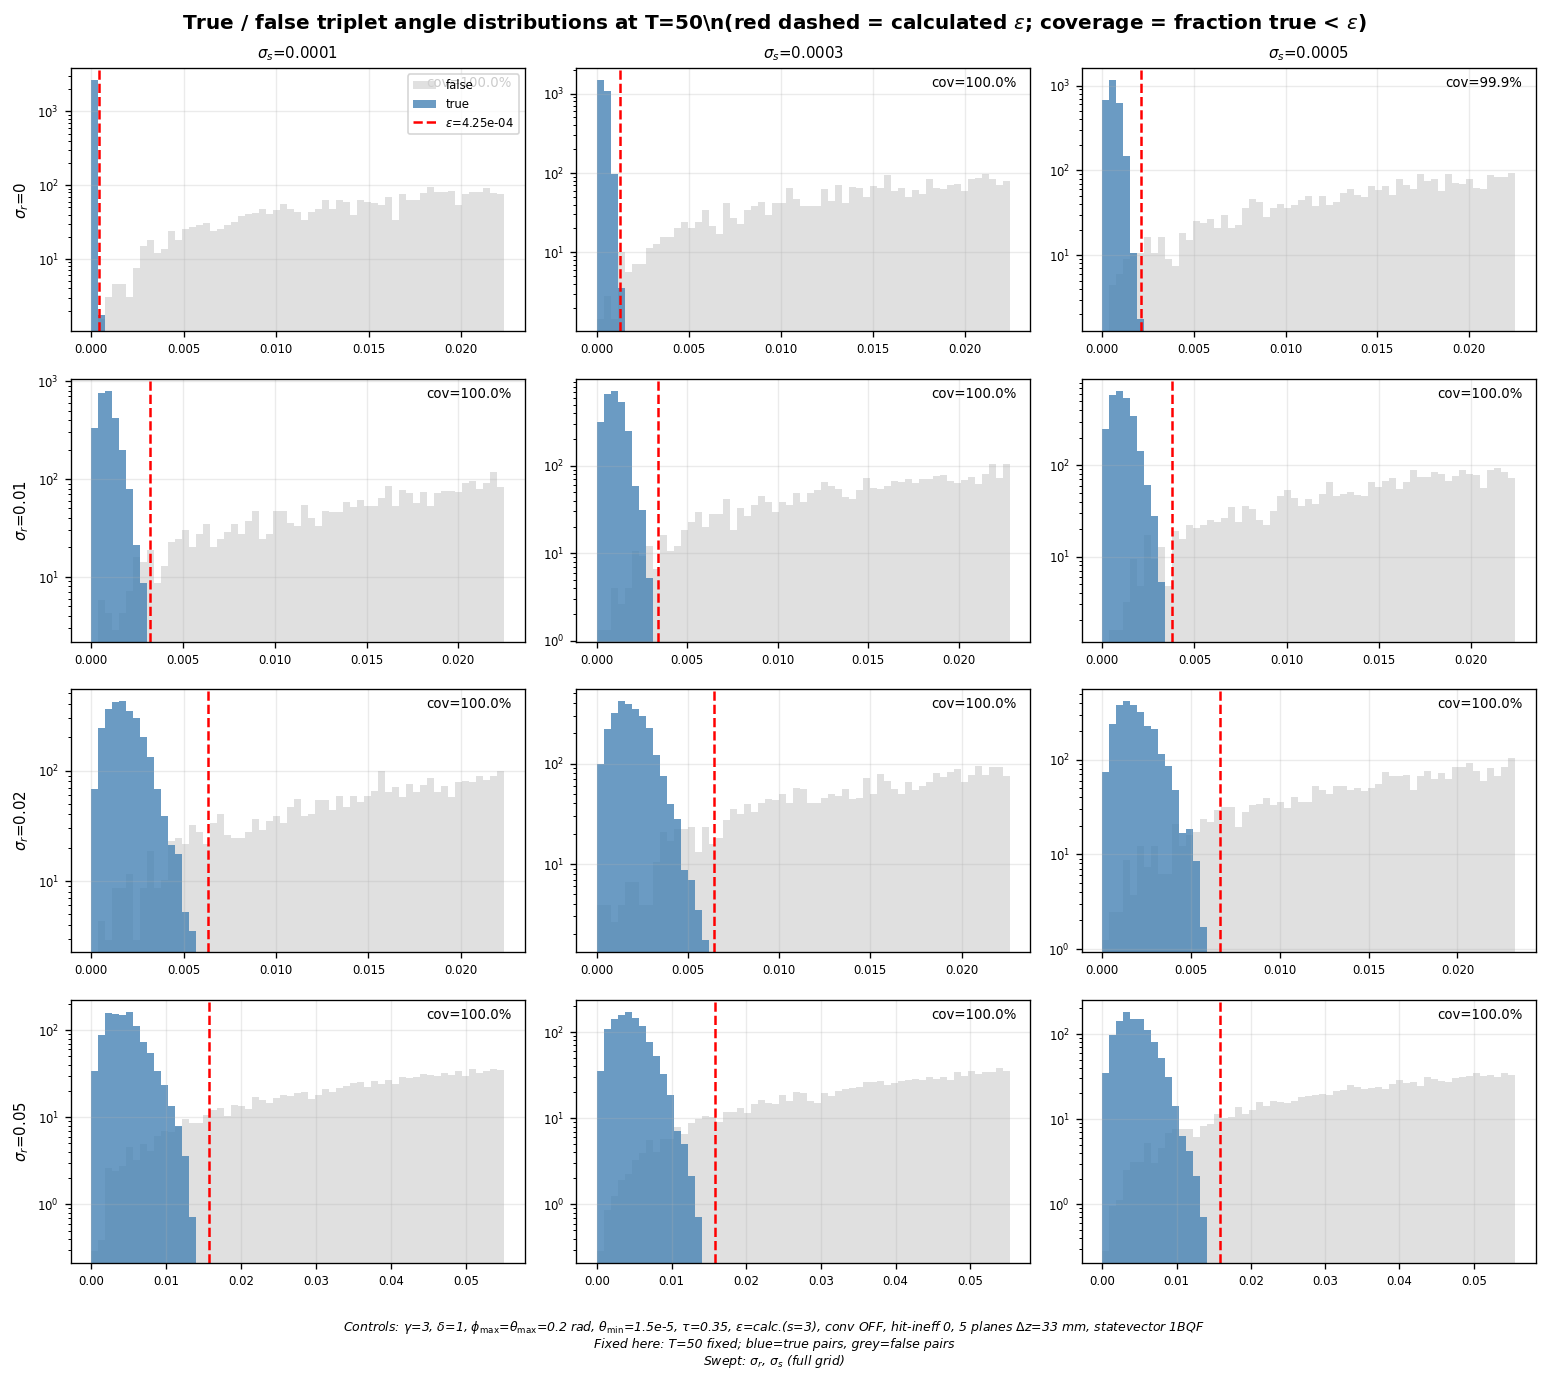

Saved → /data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Epsilon_study_2/figures/deep_analysis/A_formula_validation/angle_histograms_T50.pdf/png


In [5]:
# 4×3 faceted histogram: true angles, false angles, ε line
FDIR_A = FIGBASE / 'A_formula_validation'
FDIR_A.mkdir(parents=True, exist_ok=True)

n_sr, n_ss = len(sr_vals), len(ss_vals)
fig, axes = plt.subplots(n_sr, n_ss, figsize=(13, 11), sharex=False)

for ri, sr in enumerate(sr_vals):
    for ci, ss in enumerate(ss_vals):
        ax = axes[ri, ci]
        key = (sr, ss)
        if key not in angle_cells:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes)
            continue
        d = angle_cells[key]
        eps = d['epsilon']
        xlim = max(eps * 3.5, d['false'].max() * 0.01) if len(d['false']) else eps * 4
        bins = np.linspace(0, min(xlim, np.percentile(d['false'], 99.5)
                                  if len(d['false']) else eps * 4), 60)

        ax.hist(d['false'], bins=bins, color='lightgrey', alpha=0.7,
                label='false', density=True, log=True)
        ax.hist(d['true'],  bins=bins, color='steelblue', alpha=0.8,
                label='true',  density=True, log=True)
        ax.axvline(eps, color='red', ls='--', lw=1.5,
                   label=fr'$\varepsilon$={eps:.2e}')
        cov = d['coverage']
        ax.text(0.97, 0.97, f'cov={cov:.1%}', transform=ax.transAxes,
                ha='right', va='top', fontsize=8,
                color='red' if cov < 0.95 else 'black')
        if ri == 0:
            ax.set_title(rf'$\sigma_s$={ss:g}', fontsize=9)
        if ci == 0:
            ax.set_ylabel(rf'$\sigma_r$={sr:g}', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.25)

axes[0, 0].legend(fontsize=7, loc='upper right')
fig.suptitle(rf'True / false triplet angle distributions at T={T_REF}\n'
             r'(red dashed = calculated $\varepsilon$; coverage = fraction true < $\varepsilon$)',
             fontweight='bold', fontsize=12)
fig.text(0.5, -0.01, controls_caption(
    swept=rf'$\sigma_r$, $\sigma_s$ (full grid)',
    extra=f'T={T_REF} fixed; blue=true pairs, grey=false pairs'),
    ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_A / f'angle_histograms_T{T_REF}.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {FDIR_A}/angle_histograms_T{T_REF}.pdf/png')

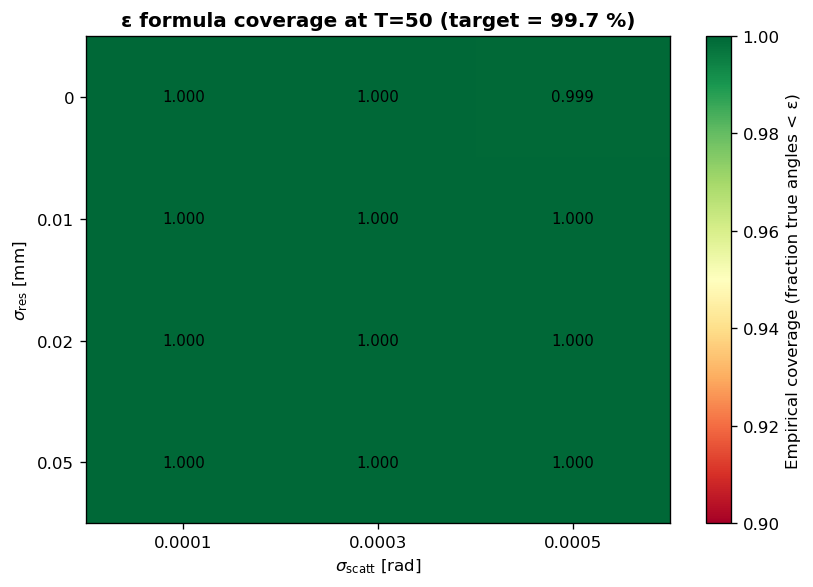

In [6]:
# Coverage heatmap
cov_grid = np.full((n_sr, n_ss), np.nan)
for ri, sr in enumerate(sr_vals):
    for ci, ss in enumerate(ss_vals):
        d = angle_cells.get((sr, ss))
        if d: cov_grid[ri, ci] = d['coverage']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cov_grid, vmin=0.9, vmax=1.0, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(n_ss)); ax.set_xticklabels([f'{s:g}' for s in ss_vals])
ax.set_yticks(range(n_sr)); ax.set_yticklabels([f'{s:g}' for s in sr_vals])
ax.set_xlabel(r'$\sigma_{\rm scatt}$ [rad]'); ax.set_ylabel(r'$\sigma_{\rm res}$ [mm]')
for ri in range(n_sr):
    for ci in range(n_ss):
        v = cov_grid[ri, ci]
        if not np.isnan(v):
            ax.text(ci, ri, f'{v:.3f}', ha='center', va='center', fontsize=9,
                    color='black')
plt.colorbar(im, ax=ax, label='Empirical coverage (fraction true angles < ε)')
ax.set_title(rf'ε formula coverage at T={T_REF} (target = 99.7 %)', fontweight='bold')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_A / f'coverage_heatmap.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section B — Formula accuracy: empirical σ vs predicted σ

The formula predicts the standard deviation of true triplet angles is
$\sigma_{\rm pred} = \varepsilon / s$ (where $s=3$).  We compare this to
$\sigma_{\rm emp} = \mathrm{std}(\text{true\_angles})$ per cell.
Points on the $y=x$ diagonal confirm the formula; deviations reveal where
the Gaussian / arctan linearisation breaks down.

In [7]:
FDIR_B = FIGBASE / 'B_formula_accuracy'
FDIR_B.mkdir(parents=True, exist_ok=True)

SCALE = 3.0
rows_B = []
for r in sens_records:
    ta = r.get('true_angles')
    if ta is None or len(ta) < 3:
        continue
    ta = np.asarray(ta, float)
    rows_B.append(dict(
        n_trk=int(r['n_trk']),
        sigma_res=float(r['sigma_res']),
        sigma_scatt=float(r['sigma_scatt']),
        epsilon=float(r['epsilon']),
        sigma_pred=float(r['epsilon']) / SCALE,
        sigma_emp=float(ta.std(ddof=1)),
    ))

B = pd.DataFrame(rows_B)
# Average over reps
B_agg = B.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).agg(
    sigma_pred=('sigma_pred', 'first'),
    sigma_emp_mean=('sigma_emp', 'mean'),
    sigma_emp_sem=('sigma_emp', lambda x: x.std(ddof=1)/np.sqrt(len(x))),
    epsilon=('epsilon', 'first'),
    n=('sigma_emp', 'count'),
).reset_index()
B_agg['residual'] = (B_agg['sigma_emp_mean'] - B_agg['sigma_pred']) / B_agg['sigma_pred']
print(B_agg[['n_trk','sigma_res','sigma_scatt','sigma_pred','sigma_emp_mean','residual']].to_string(index=False))

 n_trk  sigma_res  sigma_scatt  sigma_pred  sigma_emp_mean  residual
    10       0.00       0.0001    0.000142        0.000062 -0.560783
    10       0.00       0.0003    0.000424        0.000192 -0.547788
    10       0.00       0.0005    0.000707        0.000333 -0.528424
    10       0.01       0.0001    0.001059        0.000479 -0.548099
    10       0.01       0.0003    0.001132        0.000532 -0.529745
    10       0.01       0.0005    0.001266        0.000562 -0.555595
    10       0.02       0.0001    0.002104        0.001026 -0.512551
    10       0.02       0.0003    0.002142        0.001025 -0.521483
    10       0.02       0.0005    0.002215        0.000956 -0.568417
    10       0.05       0.0001    0.005251        0.002100 -0.600116
    10       0.05       0.0003    0.005266        0.002319 -0.559646
    10       0.05       0.0005    0.005296        0.002309 -0.563949
    20       0.00       0.0001    0.000142        0.000067 -0.528055
    20       0.00       0.0003    

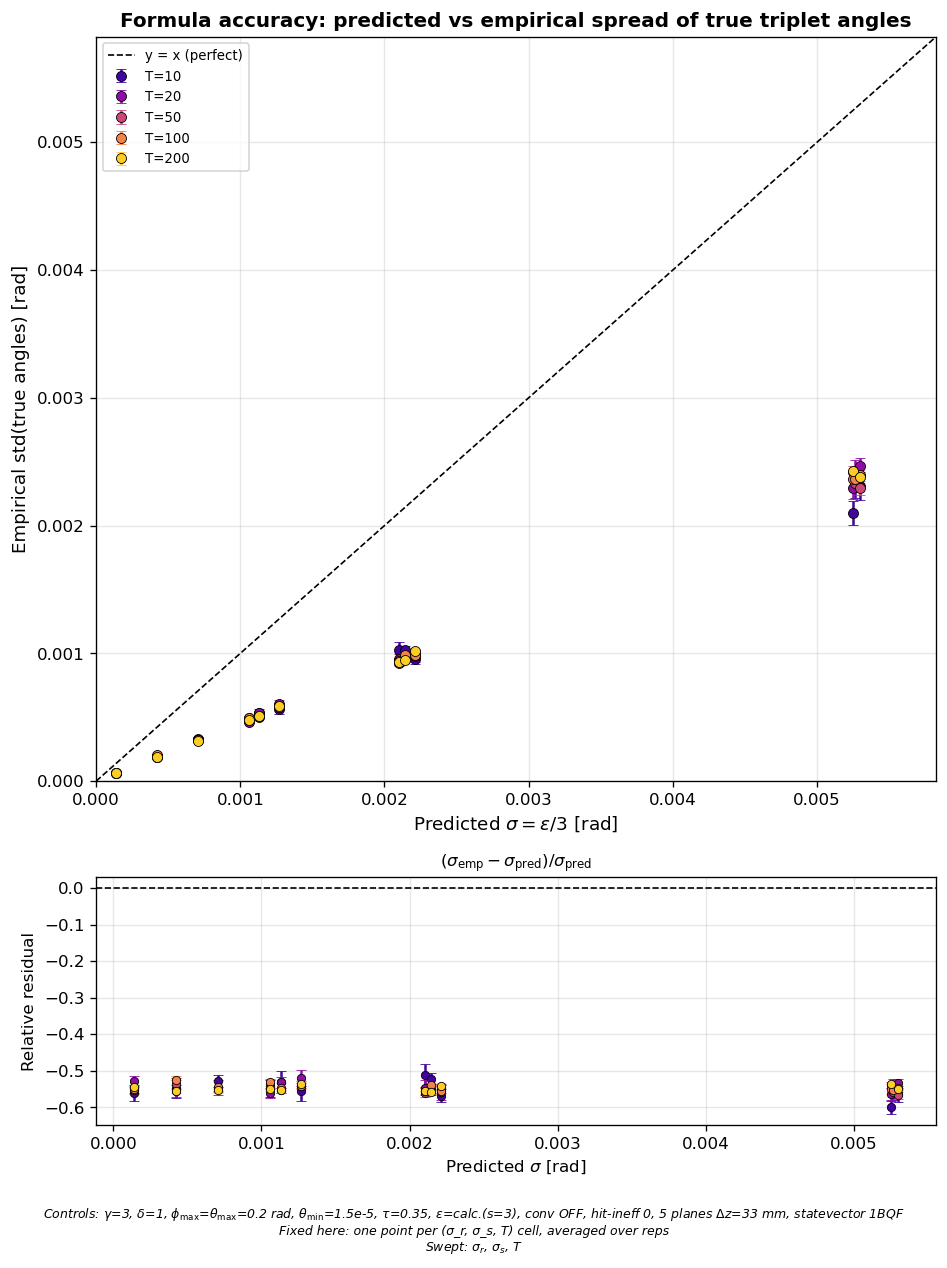

In [8]:
T_vals_B = sorted(B_agg['n_trk'].unique())
cmap_B = plt.cm.plasma(np.linspace(0.1, 0.9, max(len(T_vals_B), 2)))

fig, (ax_main, ax_res) = plt.subplots(2, 1, figsize=(8, 10),
                                       gridspec_kw={'height_ratios': [3, 1]})

all_vals = []
for T, c in zip(T_vals_B, cmap_B):
    sub = B_agg[B_agg['n_trk'] == T]
    ax_main.errorbar(sub['sigma_pred'], sub['sigma_emp_mean'],
                     yerr=sub['sigma_emp_sem'],
                     fmt='o', color=c, capsize=3, ms=6,
                     mec='black', mew=0.5, label=f'T={T}', zorder=3)
    ax_res.errorbar(sub['sigma_pred'], sub['residual'],
                    yerr=sub['sigma_emp_sem'] / sub['sigma_pred'],
                    fmt='o', color=c, capsize=3, ms=5, mec='black', mew=0.5)
    all_vals.extend(sub['sigma_pred'].tolist())
    all_vals.extend(sub['sigma_emp_mean'].tolist())

lim = max(all_vals) * 1.1
ax_main.plot([0, lim], [0, lim], 'k--', lw=1, label='y = x (perfect)')
ax_main.set_xlim(0, lim); ax_main.set_ylim(0, lim)
ax_main.set_xlabel(r'Predicted $\sigma = \varepsilon / 3$ [rad]', fontsize=11)
ax_main.set_ylabel(r'Empirical std(true angles) [rad]', fontsize=11)
ax_main.legend(fontsize=8); ax_main.grid(alpha=0.3)
ax_main.set_title('Formula accuracy: predicted vs empirical spread of true triplet angles',
                  fontweight='bold')

ax_res.axhline(0, color='k', ls='--', lw=1)
ax_res.set_xlabel(r'Predicted $\sigma$ [rad]', fontsize=10)
ax_res.set_ylabel('Relative residual', fontsize=10)
ax_res.set_title(r'$(\sigma_{\rm emp} - \sigma_{\rm pred})/\sigma_{\rm pred}$', fontsize=10)
ax_res.grid(alpha=0.3)

fig.text(0.5, -0.01, controls_caption(
    swept=r'$\sigma_r$, $\sigma_s$, T',
    extra='one point per (σ_r, σ_s, T) cell, averaged over reps'),
    ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_B / f'sigma_scatter.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section C — Score distribution overlap

How well do the classical and quantum solvers separate true from false segments,
and how does that separation change with noise?  We use the Fisher discriminant
ratio and ROC-AUC as threshold-free measures of separation quality.

In [9]:
FDIR_C = FIGBASE / 'C_score_separation'
FDIR_C.mkdir(parents=True, exist_ok=True)

def fisher_ratio(scores, truth):
    """Fisher discriminant ratio (mu_true - mu_false)^2 / (var_true + var_false)."""
    s_t = scores[truth];  s_f = scores[~truth]
    if len(s_t) < 2 or len(s_f) < 2:
        return np.nan
    return (s_t.mean() - s_f.mean()) ** 2 / (s_t.var(ddof=1) + s_f.var(ddof=1) + 1e-30)

rows_C = []
for r in sens_records:
    sc = r.get('sol_C'); sq = r.get('sol_Q'); tr = r.get('truth')
    if sc is None or tr is None:
        continue
    sc = np.asarray(sc, float); tr = np.asarray(tr, bool)
    row = dict(
        n_trk=int(r['n_trk']),
        sigma_res=float(r['sigma_res']),
        sigma_scatt=float(r['sigma_scatt']),
        fisher_C=fisher_ratio(sc, tr),
        auc_C=_auc(sc, tr),
    )
    if sq is not None:
        sq = np.asarray(sq, float)
        row['fisher_Q'] = fisher_ratio(sq, tr)
        row['auc_Q']    = _auc(sq, tr)
    else:
        row['fisher_Q'] = np.nan
        row['auc_Q']    = np.nan
    rows_C.append(row)

C = pd.DataFrame(rows_C)
C_agg = C.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).mean().reset_index()
print('Separation metrics aggregated:', C_agg.shape)
C_agg.head()

Separation metrics aggregated: (59, 7)


,n_trk,sigma_res,sigma_scatt,fisher_C,auc_C,fisher_Q,auc_Q
0,10,0.00,0.0001,11.943750,1.0,7.497773,1.000000
1,10,0.00,0.0003,11.943750,1.0,7.497773,1.000000
2,10,0.00,0.0005,11.943750,1.0,7.497773,1.000000
3,10,0.01,0.0001,11.943750,1.0,7.497773,1.000000
4,10,0.01,0.0003,11.915635,1.0,7.474043,0.999861


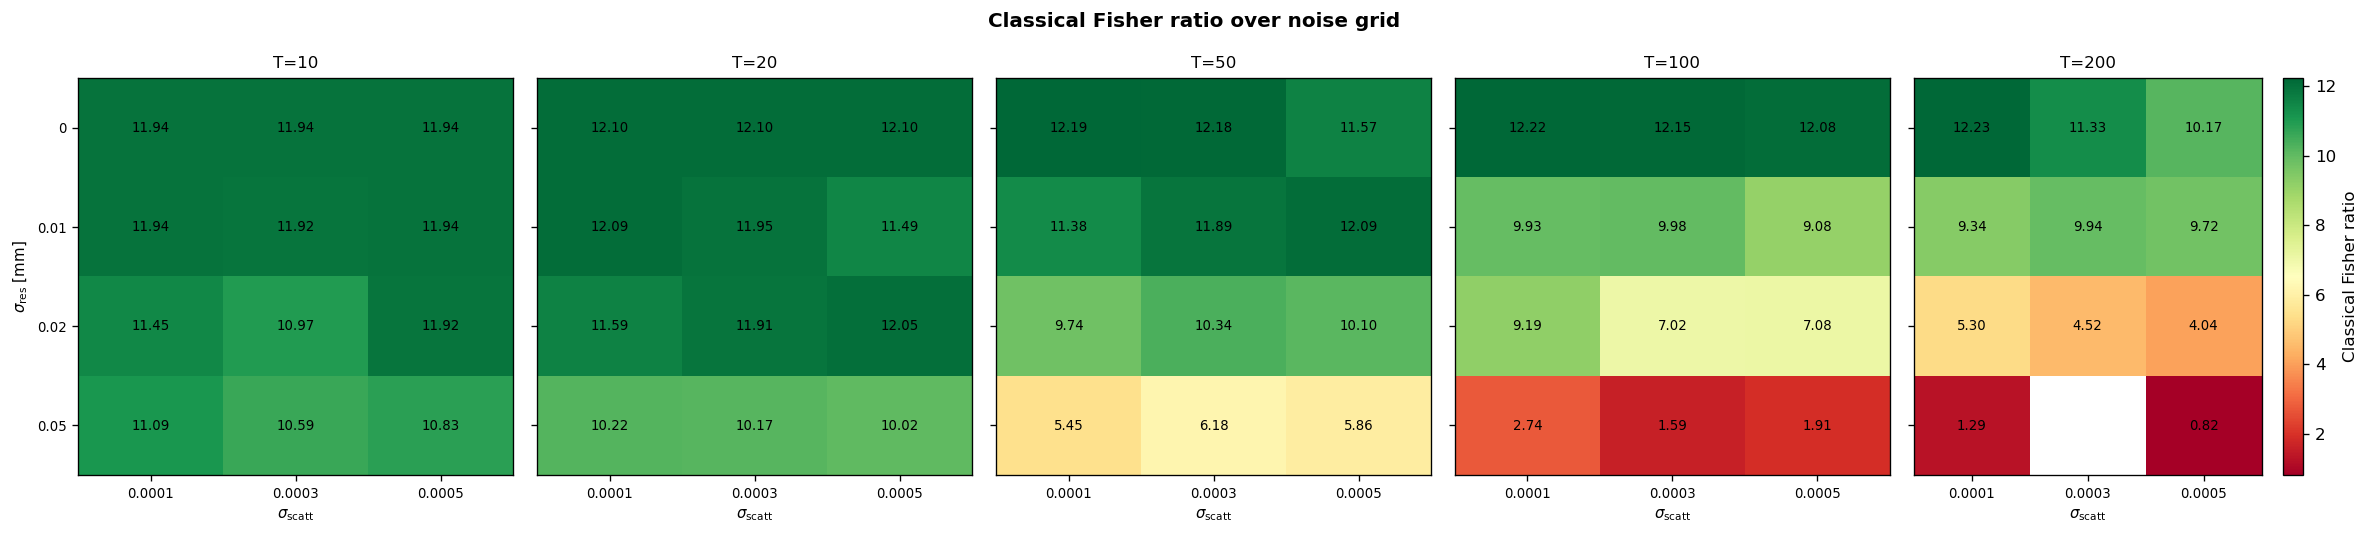

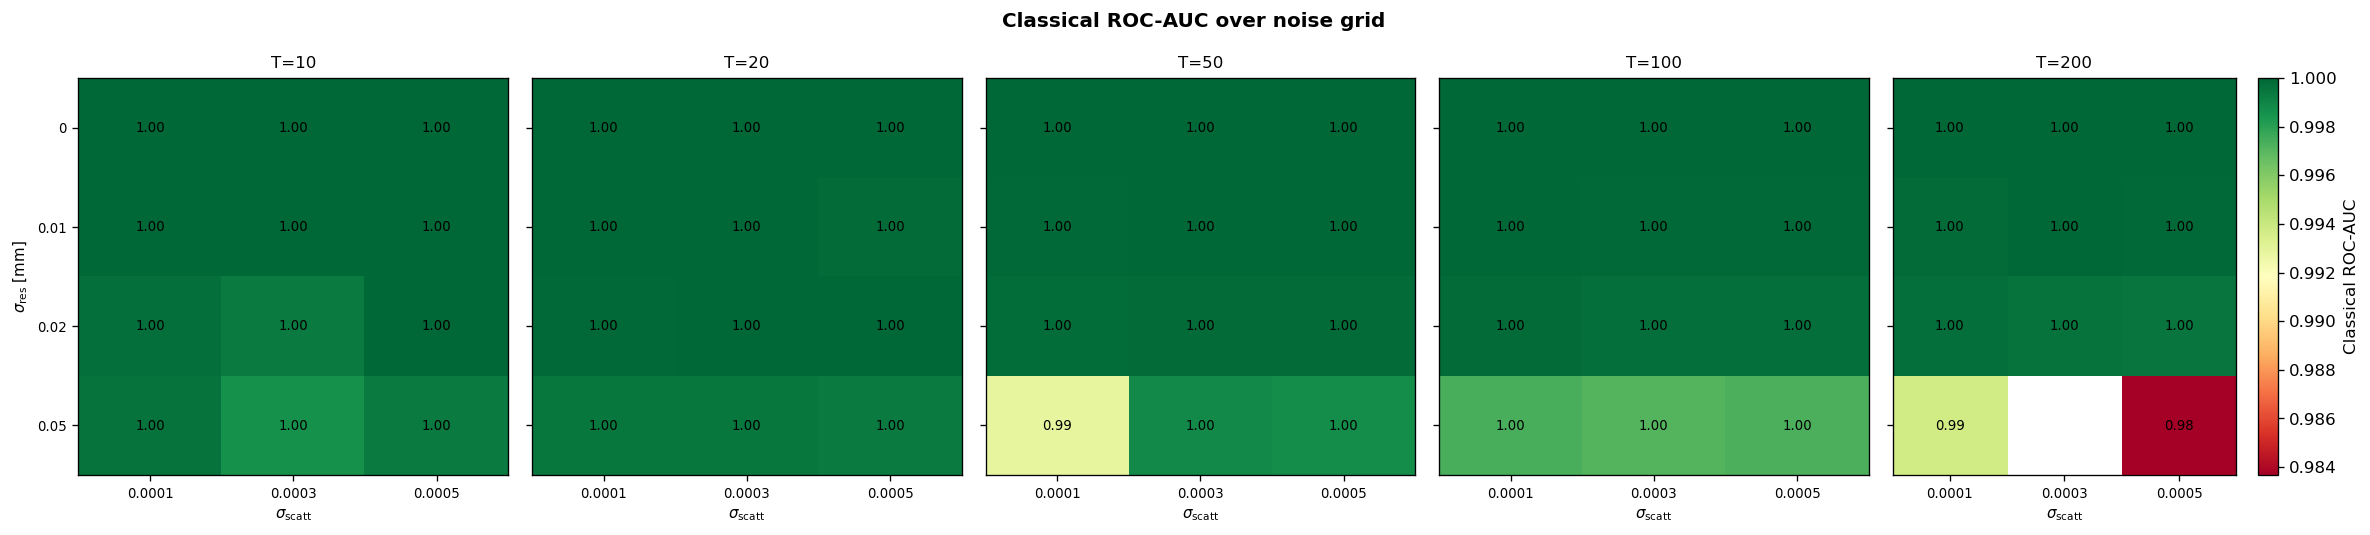

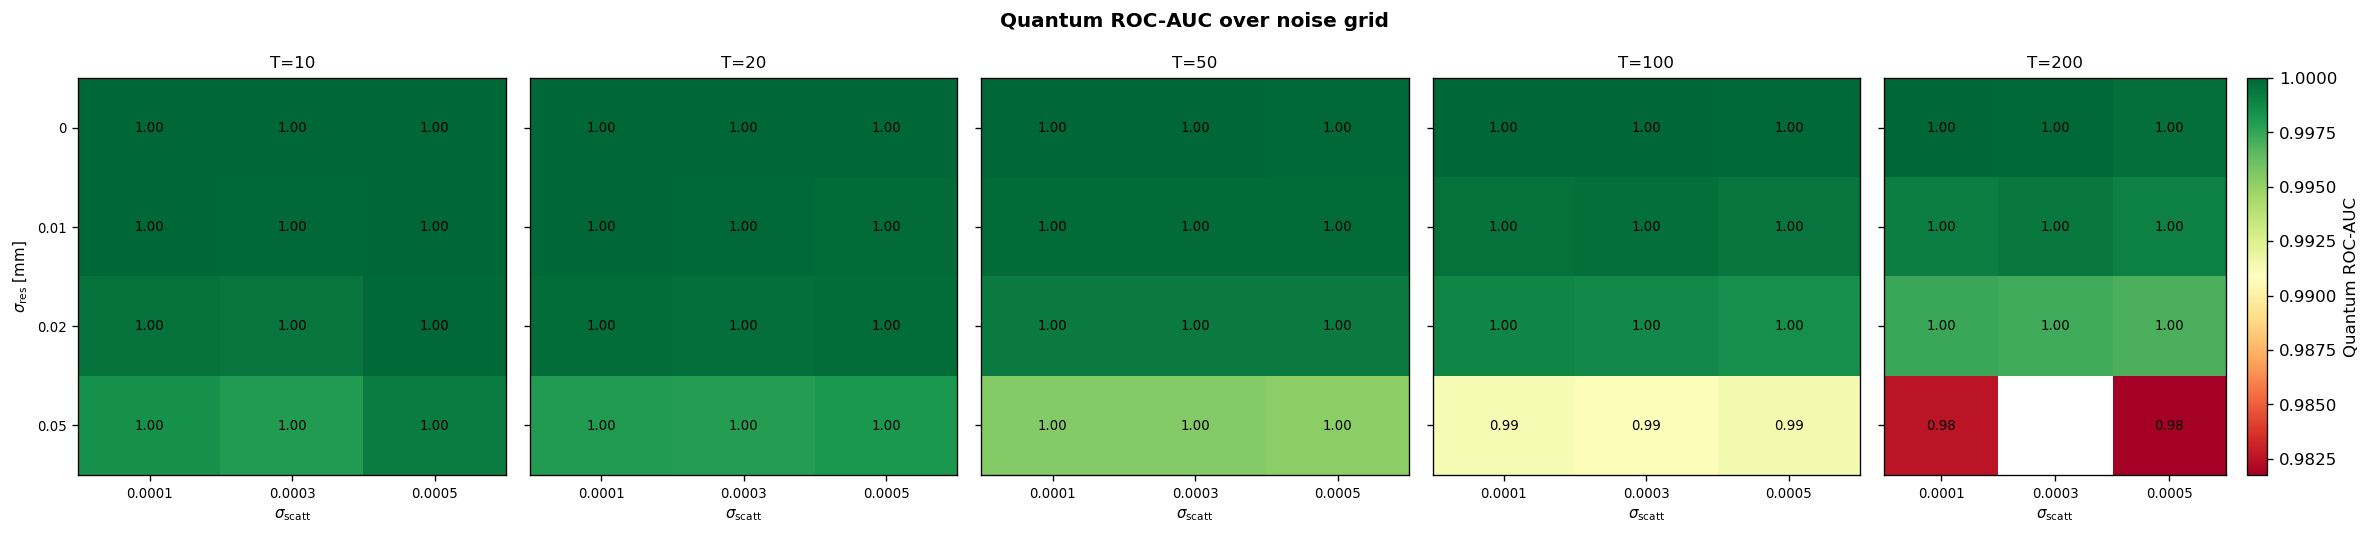

In [10]:
# Fisher ratio heatmaps over 4×3 noise grid, one column per T
T_vals_C = [t for t in [10, 20, 50, 100, 200] if t in C_agg['n_trk'].values]

for metric, label in [('fisher_C', 'Classical Fisher ratio'),
                       ('auc_C',    'Classical ROC-AUC'),
                       ('auc_Q',    'Quantum ROC-AUC')]:
    fig, axes = plt.subplots(1, len(T_vals_C), figsize=(4 * len(T_vals_C), 4.5),
                             sharey=True)
    if len(T_vals_C) == 1:
        axes = [axes]
    vmin = C_agg[metric].min(); vmax = C_agg[metric].max()
    for ax, T in zip(axes, T_vals_C):
        sub = C_agg[C_agg['n_trk'] == T]
        grid = np.full((n_sr, n_ss), np.nan)
        for ri, sr in enumerate(sr_vals):
            for ci, ss in enumerate(ss_vals):
                row = sub[(np.isclose(sub.sigma_res, sr)) &
                          (np.isclose(sub.sigma_scatt, ss))]
                if not row.empty:
                    grid[ri, ci] = float(row[metric].iloc[0])
        im = ax.imshow(grid, vmin=vmin, vmax=vmax, cmap='RdYlGn', aspect='auto')
        ax.set_xticks(range(n_ss))
        ax.set_xticklabels([f'{s:g}' for s in ss_vals], fontsize=8)
        ax.set_yticks(range(n_sr))
        ax.set_yticklabels([f'{s:g}' for s in sr_vals], fontsize=8)
        ax.set_title(f'T={T}', fontsize=10)
        ax.set_xlabel(r'$\sigma_{\rm scatt}$', fontsize=9)
        for ri2 in range(n_sr):
            for ci2 in range(n_ss):
                v = grid[ri2, ci2]
                if not np.isnan(v):
                    ax.text(ci2, ri2, f'{v:.2f}', ha='center', va='center', fontsize=8)
    axes[0].set_ylabel(r'$\sigma_{\rm res}$ [mm]', fontsize=9)
    plt.colorbar(im, ax=axes[-1], label=label)
    fig.suptitle(f'{label} over noise grid', fontweight='bold')
    plt.tight_layout()
    fname = metric.replace('_', '')
    for ext in ('pdf', 'png'):
        fig.savefig(FDIR_C / f'heatmap_{fname}.{ext}',
                    dpi=300 if ext == 'pdf' else 150,
                    bbox_inches='tight', facecolor='white')
    plt.show()

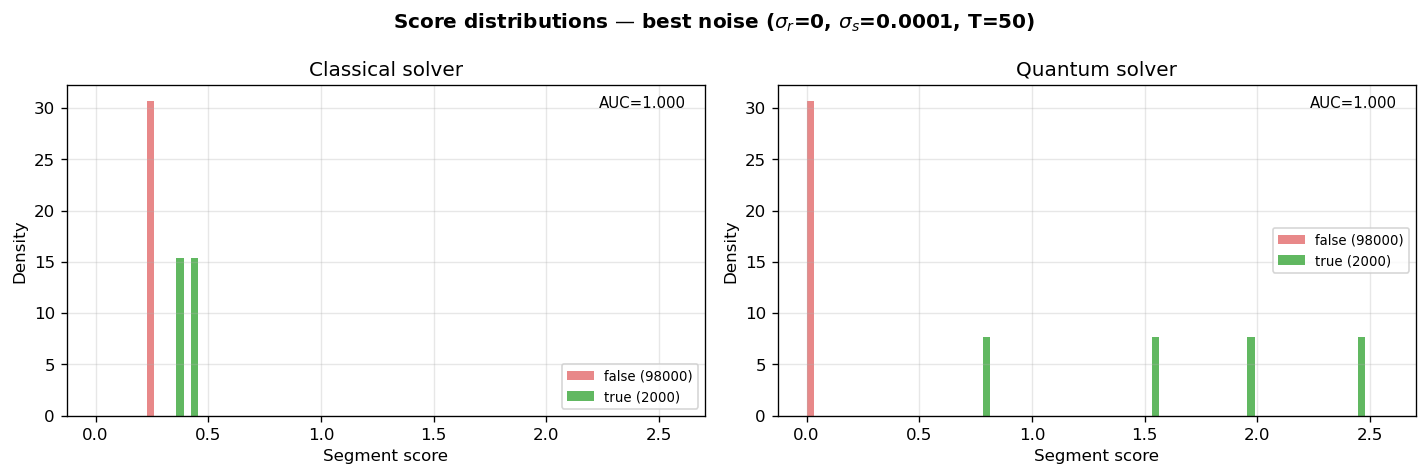

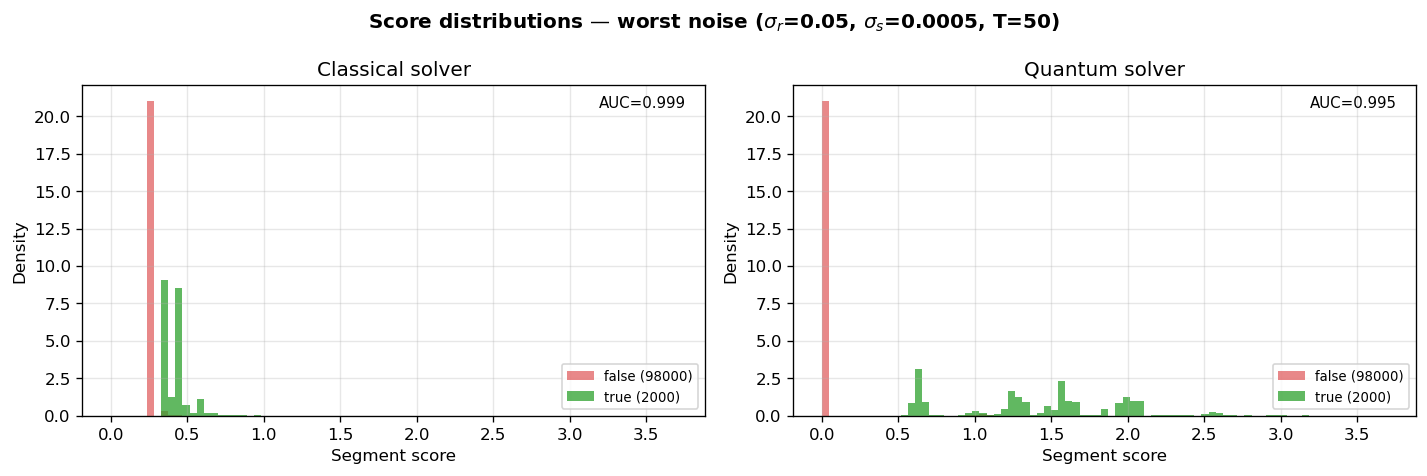

In [11]:
# Score histograms at best and worst noise conditions (T=50)
best_key  = (sr_vals[0],  ss_vals[0])   # lowest noise
worst_key = (sr_vals[-1], ss_vals[-1])  # highest noise

for label_k, key in [('best_noise', best_key), ('worst_noise', worst_key)]:
    sr, ss = key
    pool = [r for r in sens_records
            if int(r['n_trk']) == T_REF
            and np.isclose(r['sigma_res'], sr)
            and np.isclose(r['sigma_scatt'], ss)
            and r.get('sol_C') is not None]
    if not pool:
        print(f'No data for {label_k}'); continue

    sc = np.concatenate([r['sol_C'] for r in pool])
    sq = np.concatenate([r['sol_Q'] for r in pool if r.get('sol_Q') is not None])
    tr = np.concatenate([r['truth'] for r in pool]).astype(bool)
    tr_q = np.concatenate([r['truth'] for r in pool
                           if r.get('sol_Q') is not None]).astype(bool)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    bins = np.linspace(0, max(sc.max(), sq.max() if sq.size else 0) * 1.05, 80)
    for ax, scores, truth_arr, title in [
            (axes[0], sc, tr, 'Classical solver'),
            (axes[1], sq, tr_q, 'Quantum solver')]:
        if not scores.size:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes); continue
        ax.hist(scores[~truth_arr], bins=bins, alpha=0.55, color='tab:red',
                label=f'false ({(~truth_arr).sum()})', density=True)
        ax.hist(scores[truth_arr],  bins=bins, alpha=0.75, color='tab:green',
                label=f'true ({truth_arr.sum()})', density=True)
        ax.set_xlabel('Segment score'); ax.set_ylabel('Density')
        ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
        auc = _auc(scores, truth_arr)
        ax.text(0.97, 0.97, f'AUC={auc:.3f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9)
    desc = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
    fig.suptitle(f'Score distributions — {label_k.replace("_", " ")} ({desc}, T={T_REF})',
                 fontweight='bold')
    plt.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(FDIR_C / f'score_hist_{label_k}.{ext}',
                    dpi=300 if ext == 'pdf' else 150,
                    bbox_inches='tight', facecolor='white')
    plt.show()

---
## Section D — Hamiltonian matrix structure

As ε grows with noise, more false-segment triplets pass the angle cut and enter
matrix $A$ as off-diagonal couplings.  A denser $A$ means a harder linear system
for both solvers and a larger quantum circuit.

In [12]:
FDIR_D = FIGBASE / 'D_hamiltonian_structure'
FDIR_D.mkdir(parents=True, exist_ok=True)

# off-diagonal fill per segment (mean number of compatible neighbours)
sens_df2 = sens_df.copy()
sens_df2['off_diag_fill'] = (sens_df2['A_nnz'] - sens_df2['n_seg']) / sens_df2['n_seg'].clip(1)

D_agg = sens_df2.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).agg(
    n_seg_mean=('n_seg', 'mean'),
    A_nnz_mean=('A_nnz', 'mean'),
    n_qubits_mean=('n_qubits', 'mean'),
    fill_mean=('off_diag_fill', 'mean'),
).reset_index()
print(D_agg.head())

   n_trk  sigma_res  sigma_scatt  n_seg_mean  A_nnz_mean  n_qubits_mean  \
0     10       0.00       0.0001       400.0       460.0           11.0   
1     10       0.00       0.0003       400.0       460.0           11.0   
2     10       0.00       0.0005       400.0       460.0           11.0   
3     10       0.01       0.0001       400.0       460.0           11.0   
4     10       0.01       0.0003       400.0       460.2           11.0   

   fill_mean  
0     0.1500  
1     0.1500  
2     0.1500  
3     0.1500  
4     0.1505  


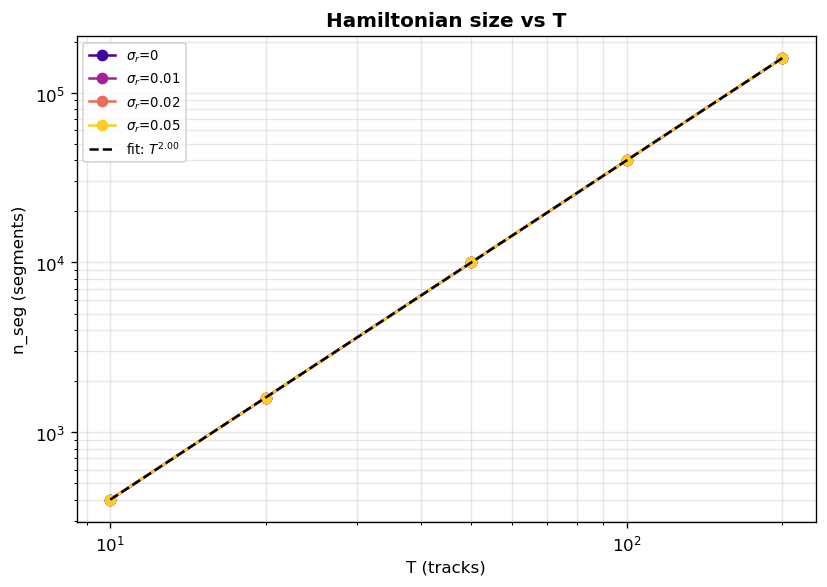

In [13]:
# n_seg vs T — expect T^2 scaling
fig, ax = plt.subplots(figsize=(7, 5))
cmap_sr2 = plt.cm.plasma(np.linspace(0.1, 0.9, max(n_sr, 2)))
for ri, sr in enumerate(sr_vals):
    sub = D_agg[np.isclose(D_agg.sigma_res, sr)].groupby('n_trk')['n_seg_mean'].mean().reset_index()
    ax.plot(sub['n_trk'], sub['n_seg_mean'], 'o-', color=cmap_sr2[ri],
            label=rf'$\sigma_r$={sr:g}')
# T^2 fit on all data
T_arr = D_agg['n_trk'].values.astype(float)
n_arr = D_agg['n_seg_mean'].values
mask = np.isfinite(T_arr) & np.isfinite(n_arr) & (T_arr > 0) & (n_arr > 0)
if mask.sum() > 2:
    coef = np.polyfit(np.log(T_arr[mask]), np.log(n_arr[mask]), 1)
    T_fit = np.logspace(np.log10(T_arr[mask].min()), np.log10(T_arr[mask].max()), 50)
    ax.plot(T_fit, np.exp(coef[1]) * T_fit ** coef[0], 'k--',
            label=rf'fit: $T^{{{coef[0]:.2f}}}$', zorder=5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('T (tracks)'); ax.set_ylabel('n_seg (segments)')
ax.set_title('Hamiltonian size vs T', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_D / f'n_seg_vs_T.{ext}',
                dpi=300 if ext == 'pdf' else 150,
                bbox_inches='tight', facecolor='white')
plt.show()

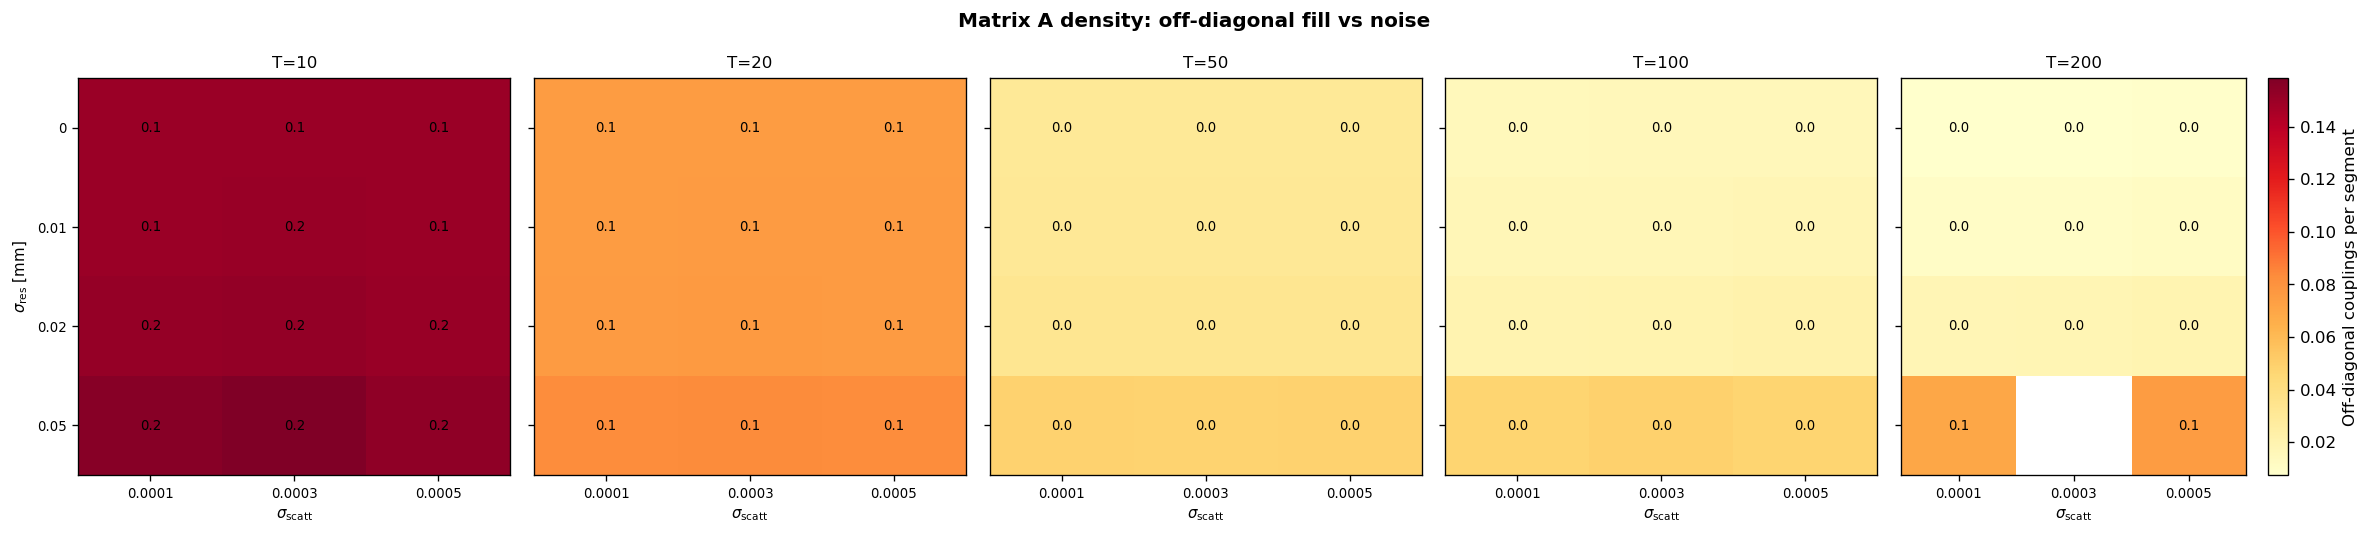

In [14]:
# Off-diagonal fill heatmaps per T
T_vals_D = [t for t in [10, 20, 50, 100, 200] if t in D_agg['n_trk'].values]
fig, axes = plt.subplots(1, len(T_vals_D), figsize=(4 * len(T_vals_D), 4.5), sharey=True)
if len(T_vals_D) == 1: axes = [axes]
vmin_f = D_agg['fill_mean'].min(); vmax_f = D_agg['fill_mean'].max()
for ax, T in zip(axes, T_vals_D):
    sub = D_agg[D_agg['n_trk'] == T]
    grid = np.full((n_sr, n_ss), np.nan)
    for ri, sr in enumerate(sr_vals):
        for ci, ss in enumerate(ss_vals):
            row = sub[(np.isclose(sub.sigma_res, sr)) & (np.isclose(sub.sigma_scatt, ss))]
            if not row.empty:
                grid[ri, ci] = float(row['fill_mean'].iloc[0])
    im = ax.imshow(grid, vmin=vmin_f, vmax=vmax_f, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n_ss)); ax.set_xticklabels([f'{s:g}' for s in ss_vals], fontsize=8)
    ax.set_yticks(range(n_sr)); ax.set_yticklabels([f'{s:g}' for s in sr_vals], fontsize=8)
    ax.set_title(f'T={T}', fontsize=10)
    ax.set_xlabel(r'$\sigma_{\rm scatt}$', fontsize=9)
    for ri2 in range(n_sr):
        for ci2 in range(n_ss):
            v = grid[ri2, ci2]
            if not np.isnan(v):
                ax.text(ci2, ri2, f'{v:.1f}', ha='center', va='center', fontsize=8)
axes[0].set_ylabel(r'$\sigma_{\rm res}$ [mm]', fontsize=9)
plt.colorbar(im, ax=axes[-1], label='Off-diagonal couplings per segment')
fig.suptitle('Matrix A density: off-diagonal fill vs noise', fontweight='bold')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_D / f'fill_heatmap.{ext}',
                dpi=300 if ext == 'pdf' else 150,
                bbox_inches='tight', facecolor='white')
plt.show()

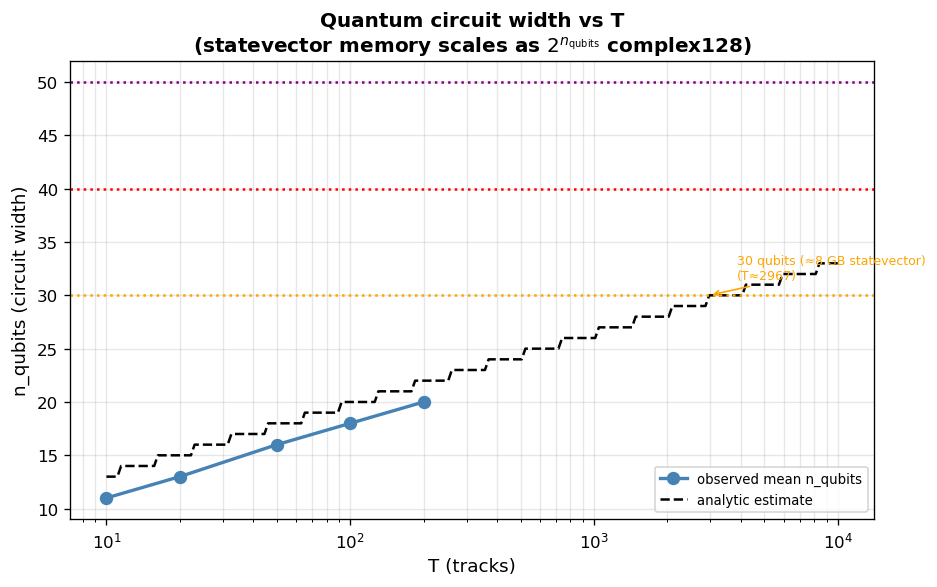

In [15]:
# n_qubits vs T with intractability thresholds
nq_by_T = (sens_df2.groupby('n_trk')['n_qubits']
           .mean().reset_index(name='n_qubits_mean'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(nq_by_T['n_trk'], nq_by_T['n_qubits_mean'], 'o-',
        color='steelblue', ms=7, lw=2, label='observed mean n_qubits')

# Extrapolate: n_qubits ~ log2(4*(N_MODULES-1)*T^2) + 2 ancilla
T_extrap = np.logspace(1, 4, 200)
N_MOD = 5
n_seg_extrap = 4 * (N_MOD - 1) * T_extrap ** 2
nq_extrap = np.ceil(np.log2(np.maximum(n_seg_extrap, 2))) + 2
ax.plot(T_extrap, nq_extrap, 'k--', lw=1.5, label='analytic estimate')

for nq_thresh, label, color in [
        (30, '30 qubits (≈8 GB statevector)', 'orange'),
        (40, '40 qubits (≈8 TB)', 'red'),
        (50, '50 qubits (near-term device limit)', 'purple')]:
    ax.axhline(nq_thresh, color=color, ls=':', lw=1.5)
    # Find crossing T
    cross = T_extrap[nq_extrap >= nq_thresh]
    if len(cross):
        ax.annotate(f'{label}\n(T≈{cross[0]:.0f})',
                    xy=(cross[0], nq_thresh),
                    xytext=(cross[0] * 1.3, nq_thresh + 1.5),
                    fontsize=7.5, color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xscale('log')
ax.set_xlabel('T (tracks)', fontsize=11)
ax.set_ylabel('n_qubits (circuit width)', fontsize=11)
ax.set_title('Quantum circuit width vs T\n'
             '(statevector memory scales as $2^{n_{\\rm qubits}}$ complex128)',
             fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_D / f'n_qubits_vs_T.{ext}',
                dpi=300 if ext == 'pdf' else 150,
                bbox_inches='tight', facecolor='white')
plt.show()

---
## Section E — Classical τ sweep and quantum separation analysis

The two solvers have fundamentally different thresholding characteristics:

**Classical solver**: Scores are continuous positive values. False segments sit just
above the bias floor (δ/(γ+δ) = 0.25), true segments score higher. A relative
threshold τ × max(score) is appropriate — sweeping τ reveals the efficiency–purity
trade-off.

**Quantum solver (1-bit HHL, statevector)**: The statevector output sends false
segments to *exactly* zero (machine precision ~10⁻¹⁴) and true segments to
distinct positive values. A relative threshold τ × max is **not appropriate**:
it discards low-scored-but-true segments, artificially capping efficiency at ~75%.
The correct operating point is simply `score > 0` (implemented as `> 1e-6` to
exclude floating-point noise). We characterise quantum performance via the
**separation gap**: min(true scores) − max(false scores). A positive gap means
perfect separation; a negative gap means some false segments have leaked above zero.

In [16]:
FDIR_E = FIGBASE / 'E_tau_and_quantum'
FDIR_E.mkdir(parents=True, exist_ok=True)

TAU_VALS  = np.linspace(0.05, 0.95, 50)
Q_THRESH  = 1e-6   # absolute threshold; false segments sit at ~1e-14

def sweep_tau_classical(sol, truth, tau_vals):
    sol = np.asarray(sol, float); truth = np.asarray(truth, bool)
    mx = sol.max(); n_true = truth.sum()
    effs, purs = [], []
    for tau in tau_vals:
        active = sol > tau * mx
        n_tp   = (active & truth).sum()
        effs.append(n_tp / max(n_true, 1))
        purs.append(n_tp / max(active.sum(), 1))
    return np.array(effs), np.array(purs)

tau_cells_C = {}   # classical tau sweep
quantum_sep  = {}  # quantum separation stats

for r in sens_records:
    if int(r['n_trk']) != T_REF:
        continue
    sc = r.get('sol_C'); sq = r.get('sol_Q'); tr = r.get('truth')
    if sc is None or tr is None:
        continue
    sc = np.asarray(sc, float); tr = np.asarray(tr, bool)
    key = (float(r['sigma_res']), float(r['sigma_scatt']))

    # Classical tau sweep
    tau_cells_C.setdefault(key, dict(effs=[], purs=[]))
    eff_C, pur_C = sweep_tau_classical(sc, tr, TAU_VALS)
    tau_cells_C[key]['effs'].append(eff_C)
    tau_cells_C[key]['purs'].append(pur_C)

    # Quantum: separation gap + correct-threshold metrics
    if sq is not None:
        sq = np.asarray(sq, float)
        false_max = float(sq[~tr].max()) if (~tr).any() else 0.0
        true_min  = float(sq[tr].min())  if tr.any()   else 0.0
        gap = true_min - false_max

        active_Q  = sq > Q_THRESH
        n_tp      = int((active_Q & tr).sum())
        eff_Q     = n_tp / max(int(tr.sum()), 1)
        pur_Q     = n_tp / max(int(active_Q.sum()), 1)

        quantum_sep.setdefault(key, dict(gaps=[], eff_Q=[], pur_Q=[]))
        quantum_sep[key]['gaps'].append(gap)
        quantum_sep[key]['eff_Q'].append(eff_Q)
        quantum_sep[key]['pur_Q'].append(pur_Q)

# Average over reps
for key, d in tau_cells_C.items():
    d['eff_mean'] = np.mean(d['effs'], axis=0)
    d['pur_mean'] = np.mean(d['purs'], axis=0)

for key, d in quantum_sep.items():
    d['gap_mean'] = float(np.mean(d['gaps']))
    d['gap_sem']  = float(np.std(d['gaps'], ddof=1) / np.sqrt(len(d['gaps'])))
    d['eff_mean'] = float(np.mean(d['eff_Q']))
    d['pur_mean'] = float(np.mean(d['pur_Q']))

print(f'Classical cells: {len(tau_cells_C)}  |  Quantum cells: {len(quantum_sep)}')
print(f'\n{"σ_r":>6} {"σ_s":>8}  {"gap":>10}  {"eff@>0":>8}  {"pur@>0":>8}')
for key in sorted(quantum_sep):
    d = quantum_sep[key]
    print(f'{key[0]:6g} {key[1]:8.1e}  {d["gap_mean"]:+10.4f}  '
          f'{d["eff_mean"]:8.3f}  {d["pur_mean"]:8.3f}')

Classical cells: 12  |  Quantum cells: 12

   σ_r      σ_s         gap    eff@>0    pur@>0
     0  1.0e-04     +0.7869     1.000     1.000
     0  3.0e-04     +0.1451     1.000     0.994
     0  5.0e-04     -0.6479     1.000     0.984
  0.01  1.0e-04     -0.6966     1.000     0.966
  0.01  3.0e-04     -0.6608     1.000     0.965
  0.01  5.0e-04     -0.4980     1.000     0.961
  0.02  1.0e-04     -1.1836     1.000     0.886
  0.02  3.0e-04     -1.0940     1.000     0.883
  0.02  5.0e-04     -1.0124     1.000     0.879
  0.05  1.0e-04     -1.6584     1.000     0.575
  0.05  3.0e-04     -1.5878     1.000     0.571
  0.05  5.0e-04     -1.6488     1.000     0.564


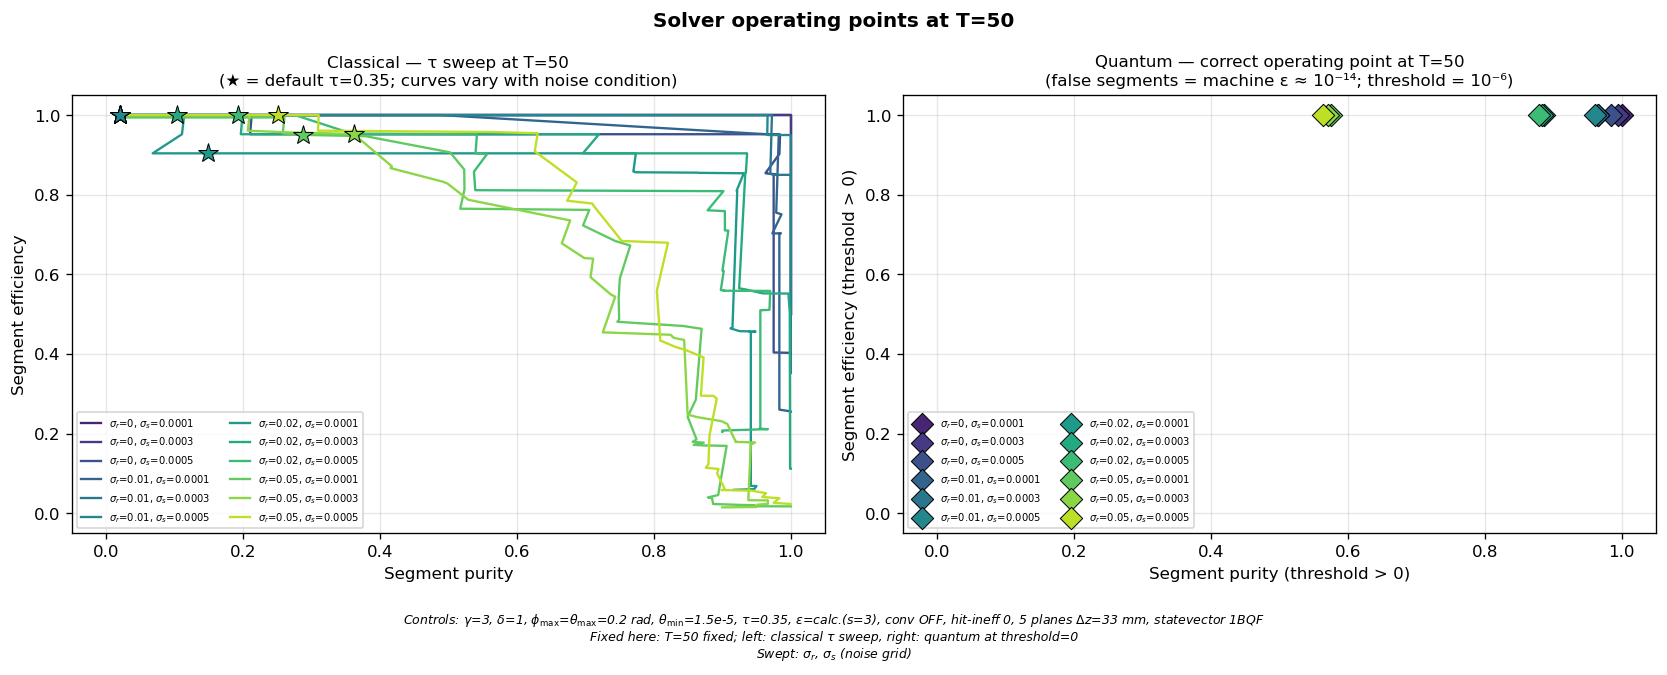

In [17]:
cmap_E = plt.cm.viridis(np.linspace(0.1, 0.9, max(len(tau_cells_C), 2)))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

TAU_DEFAULT = 0.35

# Left: classical τ sweep — parametric efficiency-purity curve
for (key, d), c in zip(sorted(tau_cells_C.items()), cmap_E):
    sr, ss = key
    lab = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
    axes[0].plot(d['pur_mean'], d['eff_mean'], '-', color=c, lw=1.4, label=lab)
    idx = np.argmin(np.abs(TAU_VALS - TAU_DEFAULT))
    axes[0].plot(d['pur_mean'][idx], d['eff_mean'][idx], '*',
                 color=c, ms=12, mec='black', mew=0.6, zorder=5)

axes[0].set_xlabel('Segment purity', fontsize=10)
axes[0].set_ylabel('Segment efficiency', fontsize=10)
axes[0].set_title(f'Classical — τ sweep at T={T_REF}\n'
                   '(★ = default τ=0.35; curves vary with noise condition)',
                   fontsize=10)
axes[0].grid(alpha=0.3); axes[0].set_xlim(-0.05, 1.05); axes[0].set_ylim(-0.05, 1.05)
axes[0].legend(fontsize=6, loc='lower left', ncol=2)

# Right: quantum operating point at correct threshold (score > 0)
for (key, d), c in zip(sorted(quantum_sep.items()), cmap_E):
    sr, ss = key
    lab = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
    axes[1].scatter(d['pur_mean'], d['eff_mean'],
                    color=c, s=90, marker='D',
                    edgecolors='black', linewidths=0.6,
                    label=lab, zorder=5)

axes[1].set_xlabel('Segment purity (threshold > 0)', fontsize=10)
axes[1].set_ylabel('Segment efficiency (threshold > 0)', fontsize=10)
axes[1].set_title(f'Quantum — correct operating point at T={T_REF}\n'
                   '(false segments = machine ε ≈ 10⁻¹⁴; threshold = 10⁻⁶)',
                   fontsize=10)
axes[1].grid(alpha=0.3); axes[1].set_xlim(-0.05, 1.05); axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(fontsize=6, loc='lower left', ncol=2)

fig.suptitle(rf'Solver operating points at T={T_REF}', fontweight='bold')
fig.text(0.5, -0.02,
         controls_caption(
             swept=r'$\sigma_r$, $\sigma_s$ (noise grid)',
             extra=f'T={T_REF} fixed; left: classical τ sweep, right: quantum at threshold=0'),
         ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_E / f'solver_operating_points.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

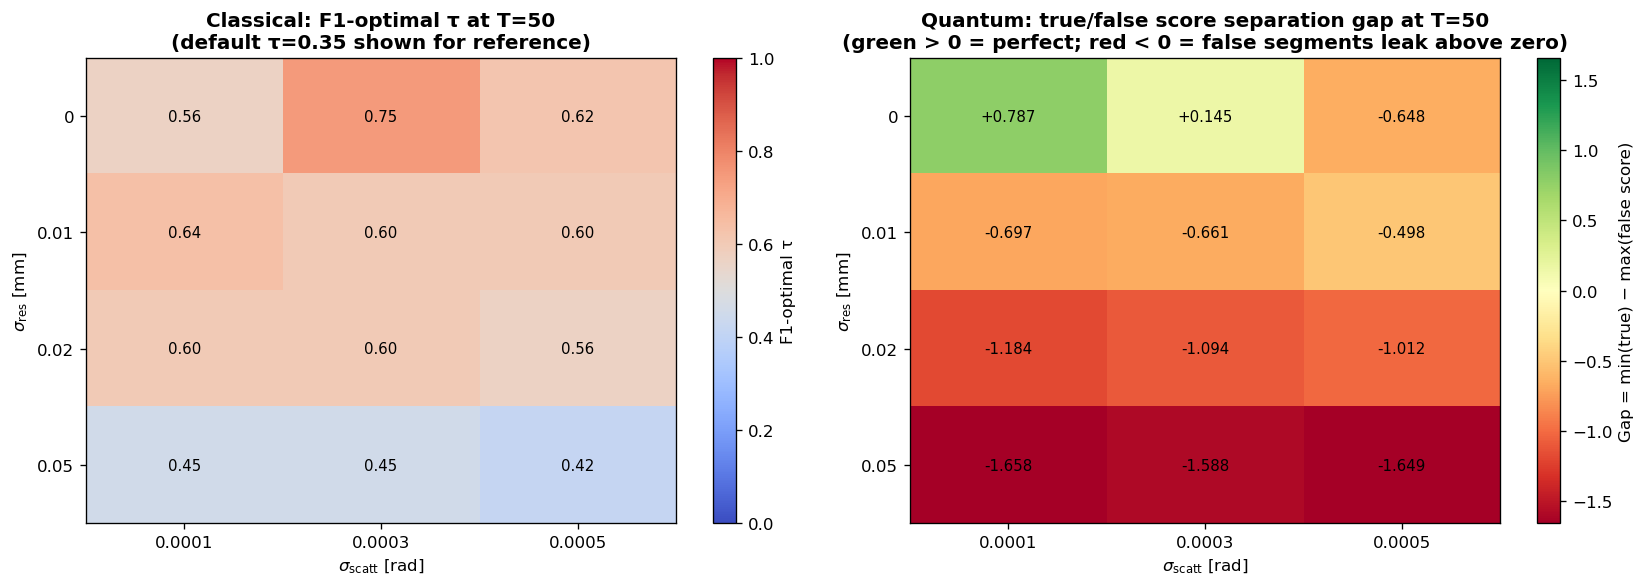

In [18]:
# Left: Classical F1-optimal τ heatmap | Right: Quantum separation gap heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Classical: F1-optimal τ
opt_tau_grid = np.full((n_sr, n_ss), np.nan)
for ri, sr in enumerate(sr_vals):
    for ci, ss in enumerate(ss_vals):
        d = tau_cells_C.get((sr, ss))
        if d is None: continue
        eff, pur = d['eff_mean'], d['pur_mean']
        f1 = 2 * eff * pur / np.where(eff + pur > 0, eff + pur, 1)
        opt_tau_grid[ri, ci] = TAU_VALS[np.argmax(f1)]

im0 = axes[0].imshow(opt_tau_grid, vmin=0.0, vmax=1.0, cmap='coolwarm', aspect='auto')
axes[0].set_xticks(range(n_ss)); axes[0].set_xticklabels([f'{s:g}' for s in ss_vals])
axes[0].set_yticks(range(n_sr)); axes[0].set_yticklabels([f'{s:g}' for s in sr_vals])
axes[0].set_xlabel(r'$\sigma_{\rm scatt}$ [rad]'); axes[0].set_ylabel(r'$\sigma_{\rm res}$ [mm]')
for ri2 in range(n_sr):
    for ci2 in range(n_ss):
        v = opt_tau_grid[ri2, ci2]
        if not np.isnan(v):
            axes[0].text(ci2, ri2, f'{v:.2f}', ha='center', va='center', fontsize=9,
                         color='white' if v < 0.25 or v > 0.75 else 'black')
plt.colorbar(im0, ax=axes[0], label='F1-optimal τ')
axes[0].set_title(rf'Classical: F1-optimal τ at T={T_REF}' + '\n(default τ=0.35 shown for reference)',
                  fontweight='bold')

# Quantum: separation gap
gap_grid = np.full((n_sr, n_ss), np.nan)
for ri, sr in enumerate(sr_vals):
    for ci, ss in enumerate(ss_vals):
        d = quantum_sep.get((sr, ss))
        if d: gap_grid[ri, ci] = d['gap_mean']

vmax_g = max(abs(np.nanmin(gap_grid)), abs(np.nanmax(gap_grid)))
im1 = axes[1].imshow(gap_grid, vmin=-vmax_g, vmax=vmax_g, cmap='RdYlGn', aspect='auto')
axes[1].set_xticks(range(n_ss)); axes[1].set_xticklabels([f'{s:g}' for s in ss_vals])
axes[1].set_yticks(range(n_sr)); axes[1].set_yticklabels([f'{s:g}' for s in sr_vals])
axes[1].set_xlabel(r'$\sigma_{\rm scatt}$ [rad]'); axes[1].set_ylabel(r'$\sigma_{\rm res}$ [mm]')
for ri2 in range(n_sr):
    for ci2 in range(n_ss):
        v = gap_grid[ri2, ci2]
        if not np.isnan(v):
            axes[1].text(ci2, ri2, f'{v:+.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im1, ax=axes[1], label='Gap = min(true) − max(false score)')
axes[1].set_title(rf'Quantum: true/false score separation gap at T={T_REF}' + '\n'
                  r'(green > 0 = perfect; red < 0 = false segments leak above zero)',
                  fontweight='bold')

plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_E / f'tau_and_quantum_gap.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section F — Geometric vs solver performance

- `ang_eff` — purely geometric acceptance at triplet level (angle < ε)
- `cls_eff` — classical solver, segment level (score > τ × max, τ=0.35)
- `q_eff`   — quantum solver, segment level using the **correct threshold** (score > 10⁻⁶)

Note: the stored `quantum_metrics_default` uses the inappropriate τ × max threshold.
We recompute `q_eff` directly from `sol_Q` here.

In [19]:
FDIR_F = FIGBASE / 'F_geometric_vs_solver'
FDIR_F.mkdir(parents=True, exist_ok=True)

Q_THRESH = 1e-6  # correct quantum threshold

rows_F = []
for r in sens_records:
    am = r.get('angle_metrics') or {}
    cm = r.get('classical_metrics_default') or {}
    sq = r.get('sol_Q')
    tr = r.get('truth')

    # Quantum efficiency with correct threshold (recomputed from sol_Q)
    q_eff_corr = np.nan
    if sq is not None and tr is not None:
        sq_arr = np.asarray(sq, float)
        tr_arr = np.asarray(tr, bool)
        active = sq_arr > Q_THRESH
        q_eff_corr = int((active & tr_arr).sum()) / max(int(tr_arr.sum()), 1)

    rows_F.append(dict(
        n_trk=int(r['n_trk']),
        sigma_res=float(r['sigma_res']),
        sigma_scatt=float(r['sigma_scatt']),
        ang_eff=am.get('segment_efficiency', np.nan),
        cls_eff=cm.get('segment_efficiency', np.nan),
        q_eff=q_eff_corr,
    ))

F = pd.DataFrame(rows_F)
F_agg = F.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).mean().reset_index()
F_agg['delta_C'] = F_agg['cls_eff'] - F_agg['ang_eff']
F_agg['delta_Q'] = F_agg['q_eff']   - F_agg['ang_eff']
print(F_agg[['n_trk','sigma_res','sigma_scatt','ang_eff','cls_eff','q_eff']].to_string(index=False))

 n_trk  sigma_res  sigma_scatt  ang_eff  cls_eff   q_eff
    10       0.00       0.0001 1.000000 1.000000 1.00000
    10       0.00       0.0003 1.000000 1.000000 1.00000
    10       0.00       0.0005 1.000000 1.000000 1.00000
    10       0.01       0.0001 1.000000 1.000000 1.00000
    10       0.01       0.0003 1.000000 1.000000 1.00000
    10       0.01       0.0005 1.000000 1.000000 1.00000
    10       0.02       0.0001 1.000000 1.000000 1.00000
    10       0.02       0.0003 1.000000 1.000000 1.00000
    10       0.02       0.0005 1.000000 1.000000 1.00000
    10       0.05       0.0001 1.000000 1.000000 1.00000
    10       0.05       0.0003 1.000000 1.000000 1.00000
    10       0.05       0.0005 1.000000 1.000000 1.00000
    20       0.00       0.0001 1.000000 1.000000 1.00000
    20       0.00       0.0003 1.000000 1.000000 1.00000
    20       0.00       0.0005 1.000000 1.000000 1.00000
    20       0.01       0.0001 1.000000 1.000000 1.00000
    20       0.01       0.0003 

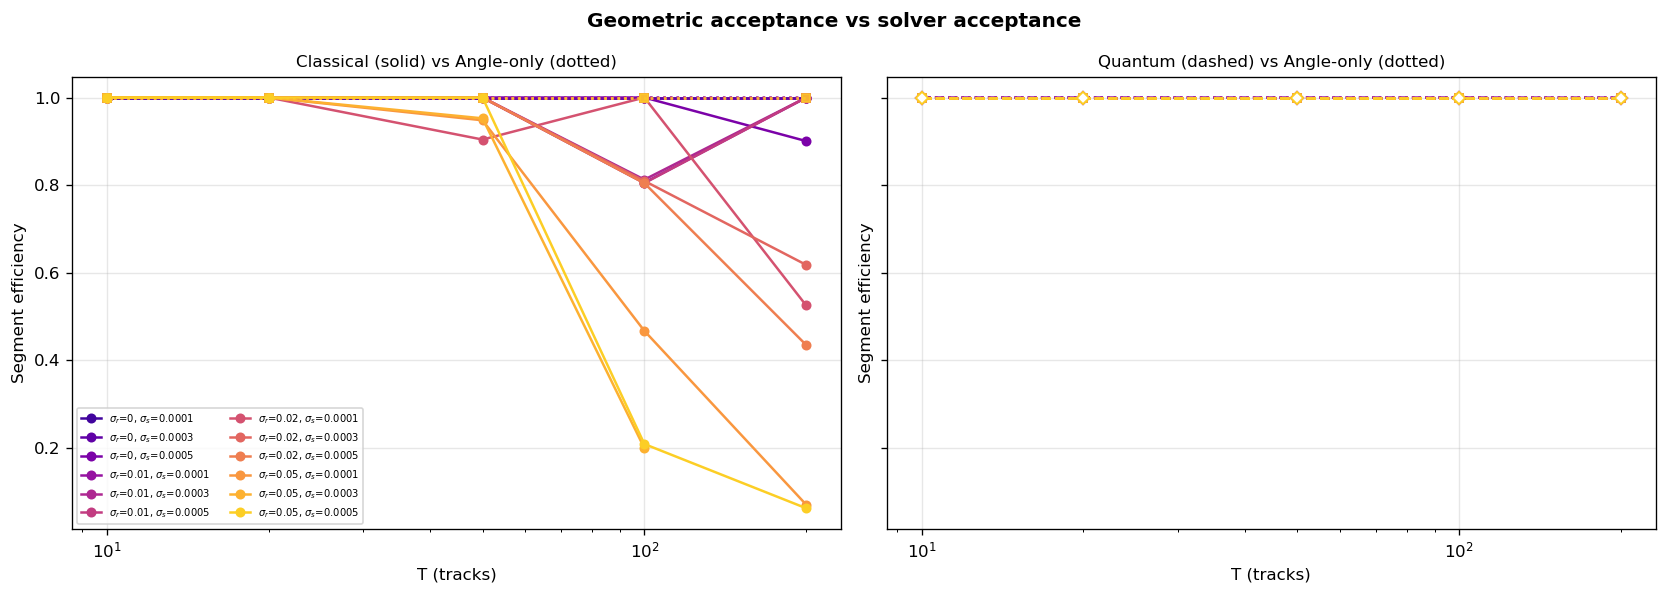

In [20]:
# All three efficiencies vs T per noise condition
T_vals_F = sorted(F_agg['n_trk'].unique())
cmap_F = plt.cm.plasma(np.linspace(0.1, 0.9, max(len(sr_vals) * len(ss_vals), 2)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
idx_c = 0
for sr in sr_vals:
    for ss in ss_vals:
        sub = F_agg[(np.isclose(F_agg.sigma_res, sr)) &
                    (np.isclose(F_agg.sigma_scatt, ss))].sort_values('n_trk')
        if sub.empty: idx_c += 1; continue
        c = cmap_F[idx_c % len(cmap_F)]
        lab = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
        axes[0].plot(sub['n_trk'], sub['ang_eff'], 's:', color=c, ms=5, alpha=0.6)
        axes[0].plot(sub['n_trk'], sub['cls_eff'], 'o-', color=c, ms=5, lw=1.5,
                     label=lab)
        axes[1].plot(sub['n_trk'], sub['ang_eff'], 's:', color=c, ms=5, alpha=0.6)
        axes[1].plot(sub['n_trk'], sub['q_eff'],   'D--', color=c, ms=5, lw=1.5,
                     mfc='white', label=lab)
        idx_c += 1

for ax, title in [(axes[0], 'Classical (solid) vs Angle-only (dotted)'),
                  (axes[1], 'Quantum (dashed) vs Angle-only (dotted)')]:
    ax.set_xscale('log'); ax.set_xlabel('T (tracks)', fontsize=10)
    ax.set_ylabel('Segment efficiency', fontsize=10)
    ax.set_title(title, fontsize=10); ax.grid(alpha=0.3)
axes[0].legend(fontsize=6, loc='lower left', ncol=2)
fig.suptitle('Geometric acceptance vs solver acceptance', fontweight='bold')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_F / f'efficiency_comparison.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

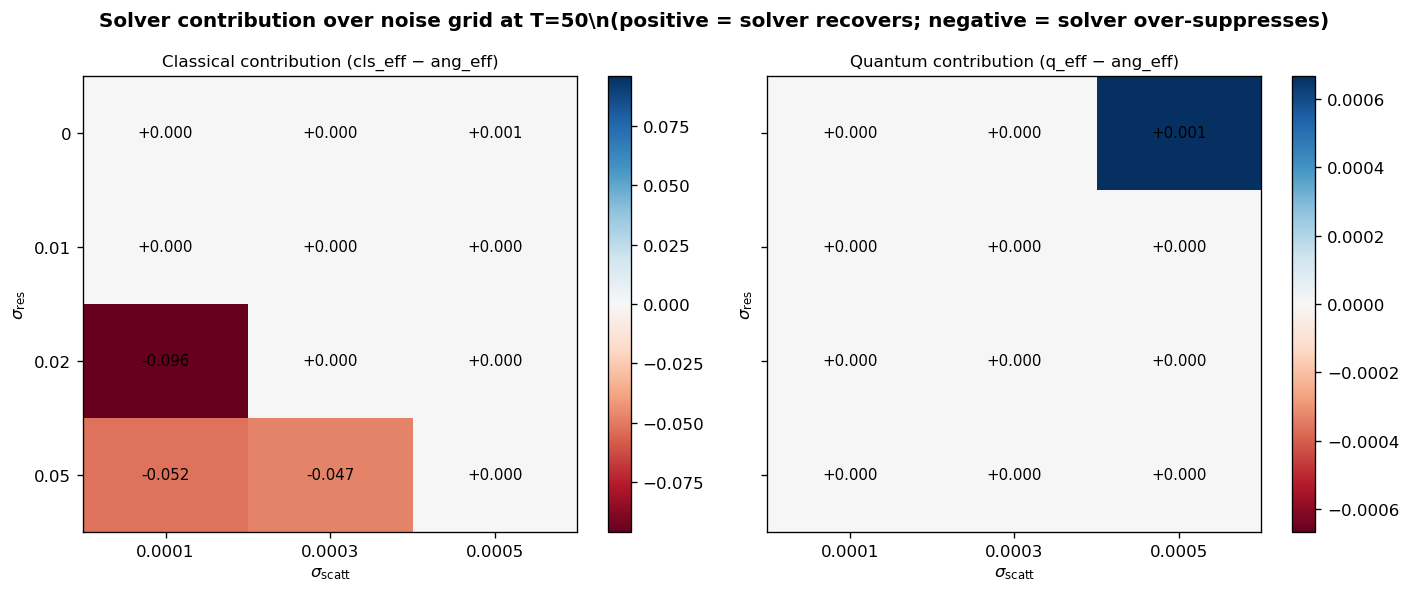

In [21]:
# Solver contribution delta_C = cls_eff - ang_eff vs noise (at T=T_REF)
sub_F = F_agg[F_agg['n_trk'] == T_REF].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, col, title in [
        (axes[0], 'delta_C', 'Classical contribution (cls_eff − ang_eff)'),
        (axes[1], 'delta_Q', 'Quantum contribution (q_eff − ang_eff)')]:
    grid = np.full((n_sr, n_ss), np.nan)
    for ri, sr in enumerate(sr_vals):
        for ci, ss in enumerate(ss_vals):
            row = sub_F[(np.isclose(sub_F.sigma_res, sr)) &
                        (np.isclose(sub_F.sigma_scatt, ss))]
            if not row.empty:
                grid[ri, ci] = float(row[col].iloc[0])
    vext = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, vmin=-vext, vmax=vext, cmap='RdBu', aspect='auto')
    ax.set_xticks(range(n_ss)); ax.set_xticklabels([f'{s:g}' for s in ss_vals])
    ax.set_yticks(range(n_sr)); ax.set_yticklabels([f'{s:g}' for s in sr_vals])
    ax.set_xlabel(r'$\sigma_{\rm scatt}$'); ax.set_ylabel(r'$\sigma_{\rm res}$')
    ax.set_title(title, fontsize=10)
    for ri2 in range(n_sr):
        for ci2 in range(n_ss):
            v = grid[ri2, ci2]
            if not np.isnan(v):
                ax.text(ci2, ri2, f'{v:+.3f}', ha='center', va='center', fontsize=9)
    plt.colorbar(im, ax=ax)
fig.suptitle(rf'Solver contribution over noise grid at T={T_REF}\n'
             r'(positive = solver recovers; negative = solver over-suppresses)',
             fontweight='bold')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_F / f'solver_contribution.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section G — Timing and quantum resource scaling

Wall-clock solve times show how tractable the algorithm is as $T$ grows,
and when the statevector quantum simulation becomes infeasible on a classical machine.

In [22]:
FDIR_G = FIGBASE / 'G_timing'
FDIR_G.mkdir(parents=True, exist_ok=True)

t_agg = (sens_df2.groupby('n_trk')
         [['t_gen', 't_angles', 't_classical', 't_q']]
         .mean().reset_index())
print(t_agg)

   n_trk     t_gen    t_angles  t_classical           t_q
0     10  0.001193    0.339143     0.004770      3.543104
1     20  0.001903    0.853767     0.007239      6.942099
2     50  0.003975    6.430474     0.113890    152.272890
3    100  0.007823   47.697887     0.200072   3566.894529
4    200  0.016871  393.037204     0.544330  31268.308989


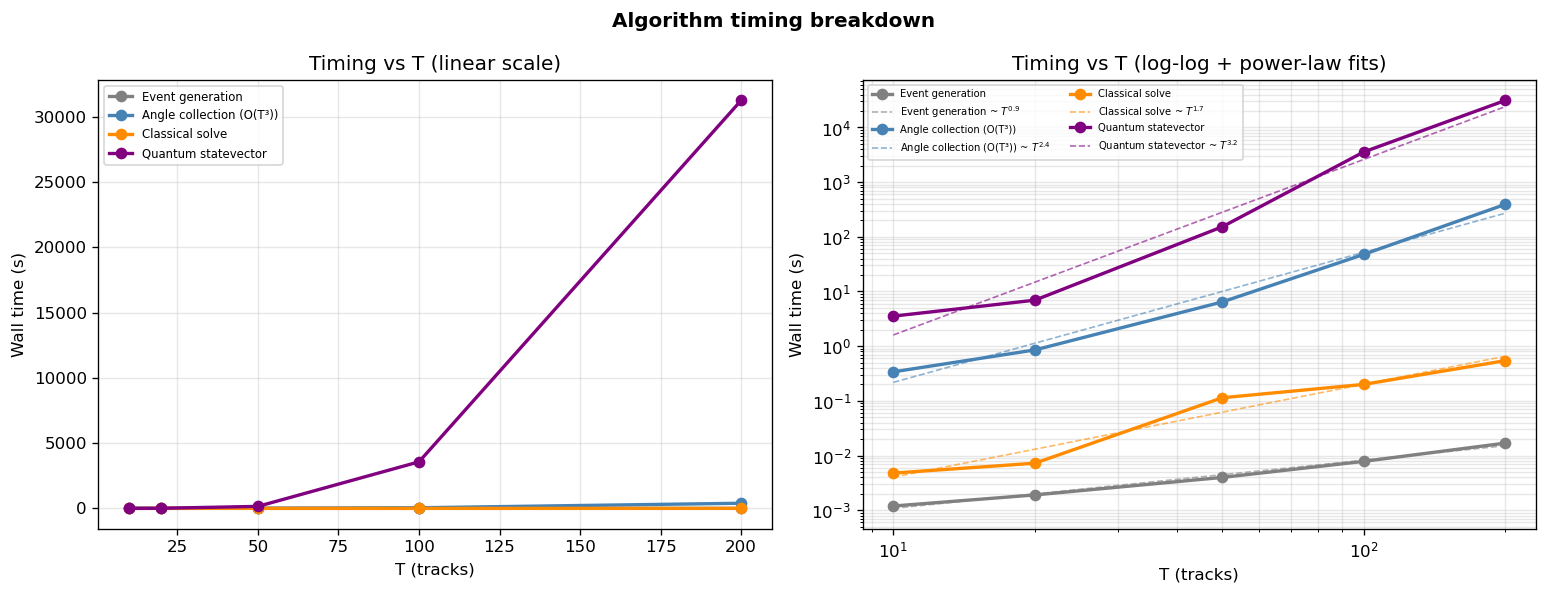

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

T_arr_t = t_agg['n_trk'].values.astype(float)
colors_t = {'t_gen': 'grey', 't_angles': 'steelblue',
             't_classical': 'darkorange', 't_q': 'purple'}
labels_t = {'t_gen': 'Event generation', 't_angles': 'Angle collection (O(T³))',
             't_classical': 'Classical solve', 't_q': 'Quantum statevector'}

for col, c, lbl in [(k, colors_t[k], labels_t[k]) for k in colors_t]:
    y = t_agg[col].values.astype(float)
    mask = np.isfinite(y) & (y > 0)
    if mask.sum() < 2:
        continue
    axes[0].plot(T_arr_t[mask], y[mask], 'o-', color=c, ms=6, lw=2, label=lbl)
    axes[1].plot(T_arr_t[mask], y[mask], 'o-', color=c, ms=6, lw=2, label=lbl)
    # Power-law fit on log-log
    coef = np.polyfit(np.log(T_arr_t[mask]), np.log(y[mask]), 1)
    T_fit = np.logspace(np.log10(T_arr_t[mask].min()),
                        np.log10(T_arr_t[mask].max()), 50)
    axes[1].plot(T_fit, np.exp(coef[1]) * T_fit ** coef[0],
                 '--', color=c, lw=1, alpha=0.6,
                 label=rf'{lbl} ~ $T^{{{coef[0]:.1f}}}$')

axes[0].set_xlabel('T (tracks)'); axes[0].set_ylabel('Wall time (s)')
axes[0].set_title('Timing vs T (linear scale)'); axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('T (tracks)'); axes[1].set_ylabel('Wall time (s)')
axes[1].set_title('Timing vs T (log-log + power-law fits)')
axes[1].legend(fontsize=6, ncol=2); axes[1].grid(alpha=0.3, which='both')

fig.suptitle('Algorithm timing breakdown', fontweight='bold')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_G / f'timing_vs_T.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Section H — Full T × noise landscape

How do segment-level metrics behave across *all* track densities and noise conditions
simultaneously?  This section gives the overview that contextualises every earlier plot:

- Classical efficiency collapses with T and noise (false-segment pool ∝ T² swamps the linear system).
- Quantum efficiency (correct threshold) stays at 1.0 across the whole landscape —
  the solver always activates every true segment.
- Quantum purity and the separation gap degrade gracefully with noise and T,
  showing where false-segment leakage sets in.

In [24]:
# ── Build a comprehensive per-(T, σ_r, σ_s) aggregate with correct quantum metrics ─
FDIR_H = FIGBASE / 'H_landscape'
FDIR_H.mkdir(parents=True, exist_ok=True)

Q_THRESH = 1e-6

rows_H = []
for r in sens_records:
    sc = r.get('sol_C'); sq = r.get('sol_Q'); tr = r.get('truth')
    am = r.get('angle_metrics') or {}
    cm = r.get('classical_metrics_default') or {}
    if sc is None or tr is None:
        continue
    sc = np.asarray(sc, float); tr = np.asarray(tr, bool)

    gap = eff_Q = pur_Q = auc_Q = np.nan
    if sq is not None:
        sq = np.asarray(sq, float)
        act = sq > Q_THRESH
        n_tp = int((act & tr).sum())
        eff_Q = n_tp / max(int(tr.sum()), 1)
        pur_Q = n_tp / max(int(act.sum()), 1)
        false_max = float(sq[~tr].max()) if (~tr).any() else 0.
        true_min  = float(sq[tr].min())  if tr.any()   else 0.
        gap = true_min - false_max
        auc_Q = _auc(sq, tr)

    rows_H.append(dict(
        n_trk=int(r['n_trk']),
        sigma_res=float(r['sigma_res']),
        sigma_scatt=float(r['sigma_scatt']),
        ang_eff =am.get('segment_efficiency', np.nan),
        cls_eff =cm.get('segment_efficiency', np.nan),
        cls_pur =cm.get('segment_purity', np.nan),
        cls_fr  =cm.get('segment_false_rate', np.nan),
        q_eff=eff_Q, q_pur=pur_Q, gap=gap,
        auc_C=_auc(sc, tr), auc_Q=auc_Q,
        n_true=int(tr.sum()), n_false=int((~tr).sum()),
        n_seg=int(r.get('n_seg', 0)),
    ))

H = pd.DataFrame(rows_H)
H_agg = H.groupby(['n_trk', 'sigma_res', 'sigma_scatt']).mean().reset_index()
T_all = sorted(H_agg['n_trk'].unique())

print(f"Cells: {len(H_agg)}  |  T values: {T_all}")
print(H_agg[['n_trk','sigma_res','sigma_scatt','cls_eff','q_eff','cls_pur','q_pur','gap']].to_string(index=False))

Cells: 59  |  T values: [np.int64(10), np.int64(20), np.int64(50), np.int64(100), np.int64(200)]
 n_trk  sigma_res  sigma_scatt  cls_eff   q_eff  cls_pur    q_pur        gap
    10       0.00       0.0001 1.000000 1.00000 0.100000 1.000000   0.374490
    10       0.00       0.0003 1.000000 1.00000 0.100000 1.000000   0.374490
    10       0.00       0.0005 1.000000 1.00000 0.100000 1.000000   0.374490
    10       0.01       0.0001 1.000000 1.00000 0.100000 1.000000   0.374490
    10       0.01       0.0003 1.000000 1.00000 0.100000 0.995238   0.313595
    10       0.01       0.0005 1.000000 1.00000 0.100000 1.000000   0.374490
    10       0.02       0.0001 1.000000 1.00000 0.100000 0.990360   0.139137
    10       0.02       0.0003 1.000000 1.00000 0.100000 0.988037   0.114552
    10       0.02       0.0005 1.000000 1.00000 0.100000 0.995238   0.313595
    10       0.05       0.0001 1.000000 1.00000 0.100000 0.951617  -0.163731
    10       0.05       0.0003 1.000000 1.00000 0.173333

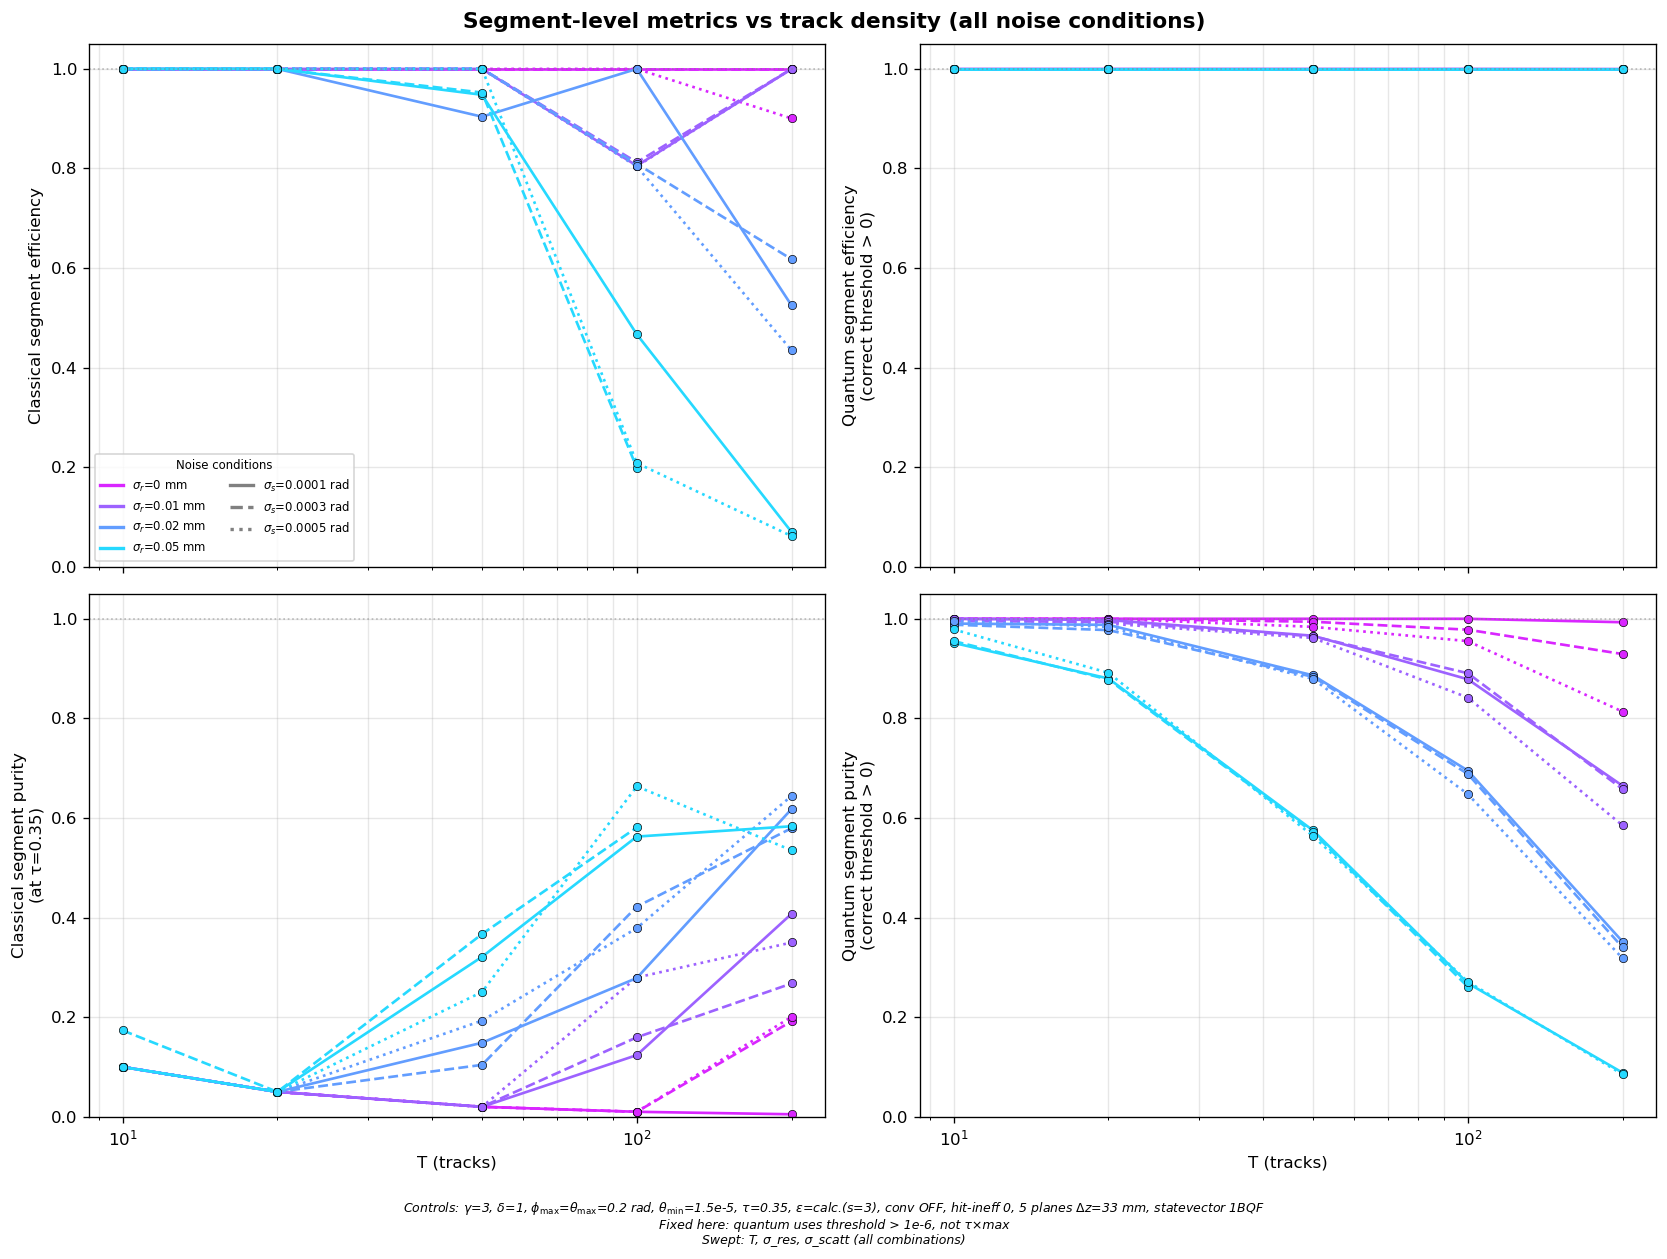

In [25]:
# ── H.1: Key metrics vs T — one curve per (σ_r, σ_s) noise condition ──────────
# Colour by σ_res (warm=high), linestyle by σ_scatt
SR_COLORS  = {sr: c for sr, c in zip(sr_vals,
              plt.cm.cool(np.linspace(0.15, 0.85, len(sr_vals)))[::-1])}
SS_STYLES  = {ss: ls for ss, ls in zip(ss_vals, ['-', '--', ':'])}

PANELS = [
    ('cls_eff', 'Classical segment efficiency',  (0.0, 1.05)),
    ('q_eff',   'Quantum segment efficiency\n(correct threshold > 0)', (0.0, 1.05)),
    ('cls_pur', 'Classical segment purity\n(at τ=0.35)',    (0.0, 1.05)),
    ('q_pur',   'Quantum segment purity\n(correct threshold > 0)', (0.0, 1.05)),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
axes = axes.ravel()

for ax, (col, ylabel, ylim) in zip(axes, PANELS):
    for sr in sr_vals:
        for ss in ss_vals:
            sub = H_agg[(np.isclose(H_agg.sigma_res, sr)) &
                        (np.isclose(H_agg.sigma_scatt, ss))].sort_values('n_trk')
            if sub.empty:
                continue
            c  = SR_COLORS[sr]
            ls = SS_STYLES[ss]
            lab = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
            ax.plot(sub['n_trk'], sub[col], color=c, ls=ls, lw=1.6,
                    marker='o', ms=5, mec='black', mew=0.4, label=lab)
    ax.set_xscale('log')
    ax.set_ylim(*ylim)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.3, which='both')
    ax.axhline(1.0, color='gray', ls=':', lw=1, alpha=0.5)

for ax in axes[2:]:
    ax.set_xlabel('T (tracks)', fontsize=10)

# Shared legend — build from sr colours + ss styles
from matplotlib.lines import Line2D
legend_handles = (
    [Line2D([0],[0], color=SR_COLORS[sr], lw=2,
             label=rf'$\sigma_r$={sr:g} mm') for sr in sr_vals] +
    [Line2D([0],[0], color='grey', ls=SS_STYLES[ss], lw=2,
             label=rf'$\sigma_s$={ss:g} rad') for ss in ss_vals]
)
axes[0].legend(handles=legend_handles, fontsize=7, loc='lower left',
               ncol=2, title='Noise conditions', title_fontsize=7)

fig.suptitle('Segment-level metrics vs track density (all noise conditions)',
             fontweight='bold', fontsize=13)
fig.text(0.5, -0.01,
         controls_caption(swept='T, σ_res, σ_scatt (all combinations)',
                          extra='quantum uses threshold > 1e-6, not τ×max'),
         ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_H / f'metrics_vs_T.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

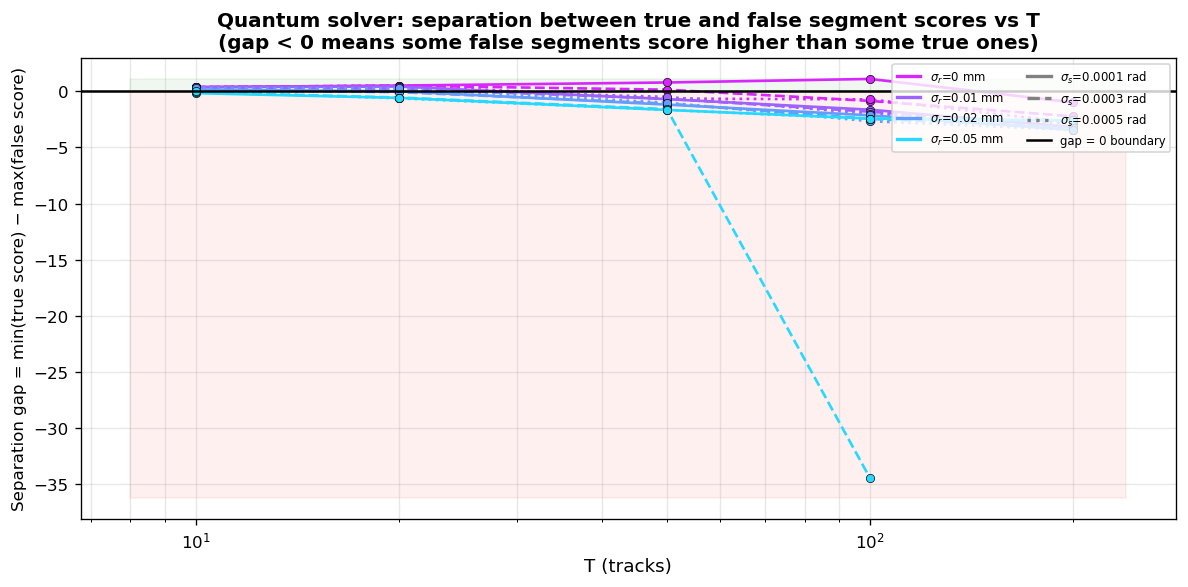

In [26]:
# ── H.2: Quantum separation gap vs T — where does false leakage begin? ────────
fig, ax = plt.subplots(figsize=(10, 5))

for sr in sr_vals:
    for ss in ss_vals:
        sub = H_agg[(np.isclose(H_agg.sigma_res, sr)) &
                    (np.isclose(H_agg.sigma_scatt, ss))].sort_values('n_trk')
        if sub.empty or sub['gap'].isna().all():
            continue
        lab = rf'$\sigma_r$={sr:g}, $\sigma_s$={ss:g}'
        ax.plot(sub['n_trk'], sub['gap'], color=SR_COLORS[sr],
                ls=SS_STYLES[ss], lw=1.6, marker='o', ms=5,
                mec='black', mew=0.4, label=lab)

ax.axhline(0, color='black', ls='-', lw=1.5,
           label='gap = 0  (separation boundary)')
ax.fill_between(
    [H_agg['n_trk'].min() * 0.8, H_agg['n_trk'].max() * 1.2],
    0, ax.get_ylim()[0] if ax.get_ylim()[0] < 0 else -5,
    color='red', alpha=0.06, label='false leakage zone (gap < 0)')
ax.fill_between(
    [H_agg['n_trk'].min() * 0.8, H_agg['n_trk'].max() * 1.2],
    0, max(H_agg['gap'].max(), 1),
    color='green', alpha=0.06, label='perfect separation (gap > 0)')

ax.set_xscale('log')
ax.set_xlabel('T (tracks)', fontsize=11)
ax.set_ylabel('Separation gap = min(true score) − max(false score)', fontsize=10)
ax.set_title('Quantum solver: separation between true and false segment scores vs T\n'
             '(gap < 0 means some false segments score higher than some true ones)',
             fontweight='bold')
ax.legend(handles=legend_handles + [
    Line2D([0],[0], color='black', lw=1.5, label='gap = 0 boundary')],
    fontsize=7, ncol=2, loc='upper right')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_H / f'quantum_gap_vs_T.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()

/tmp/claude-11298/ipykernel_31786/3953648555.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


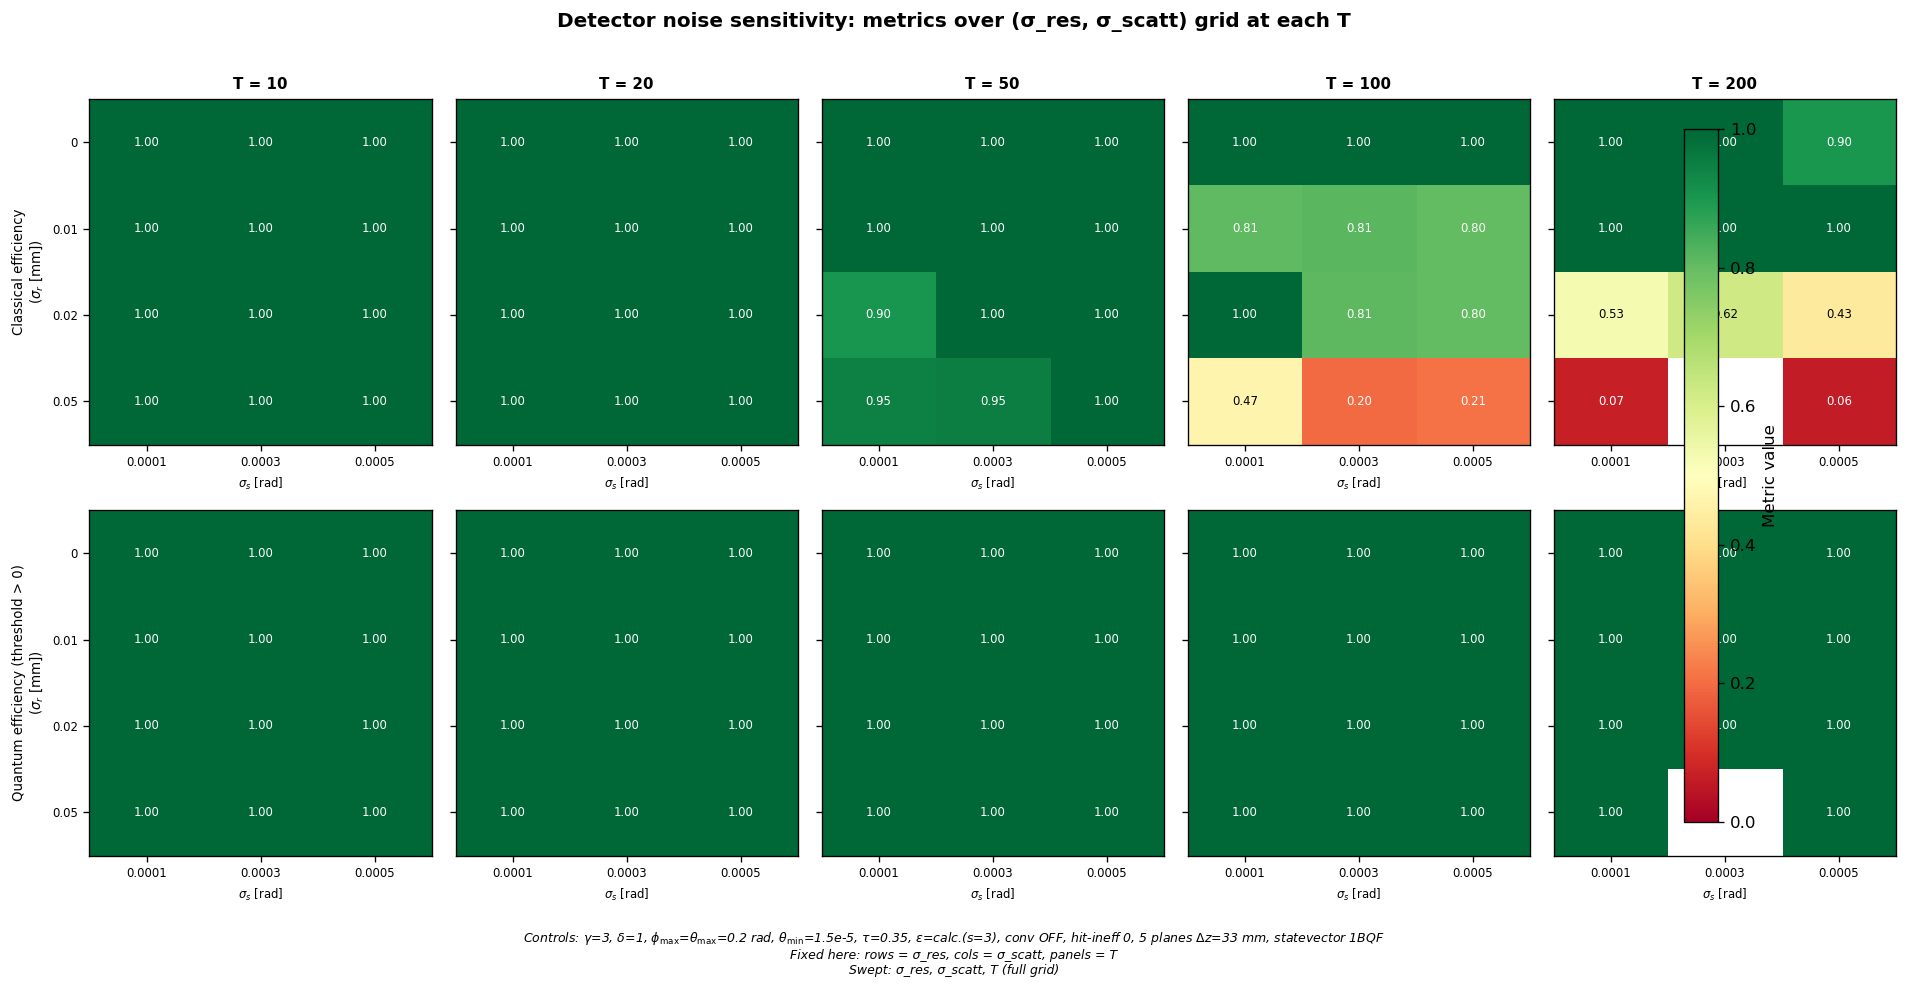

/tmp/claude-11298/ipykernel_31786/3953648555.py:55: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


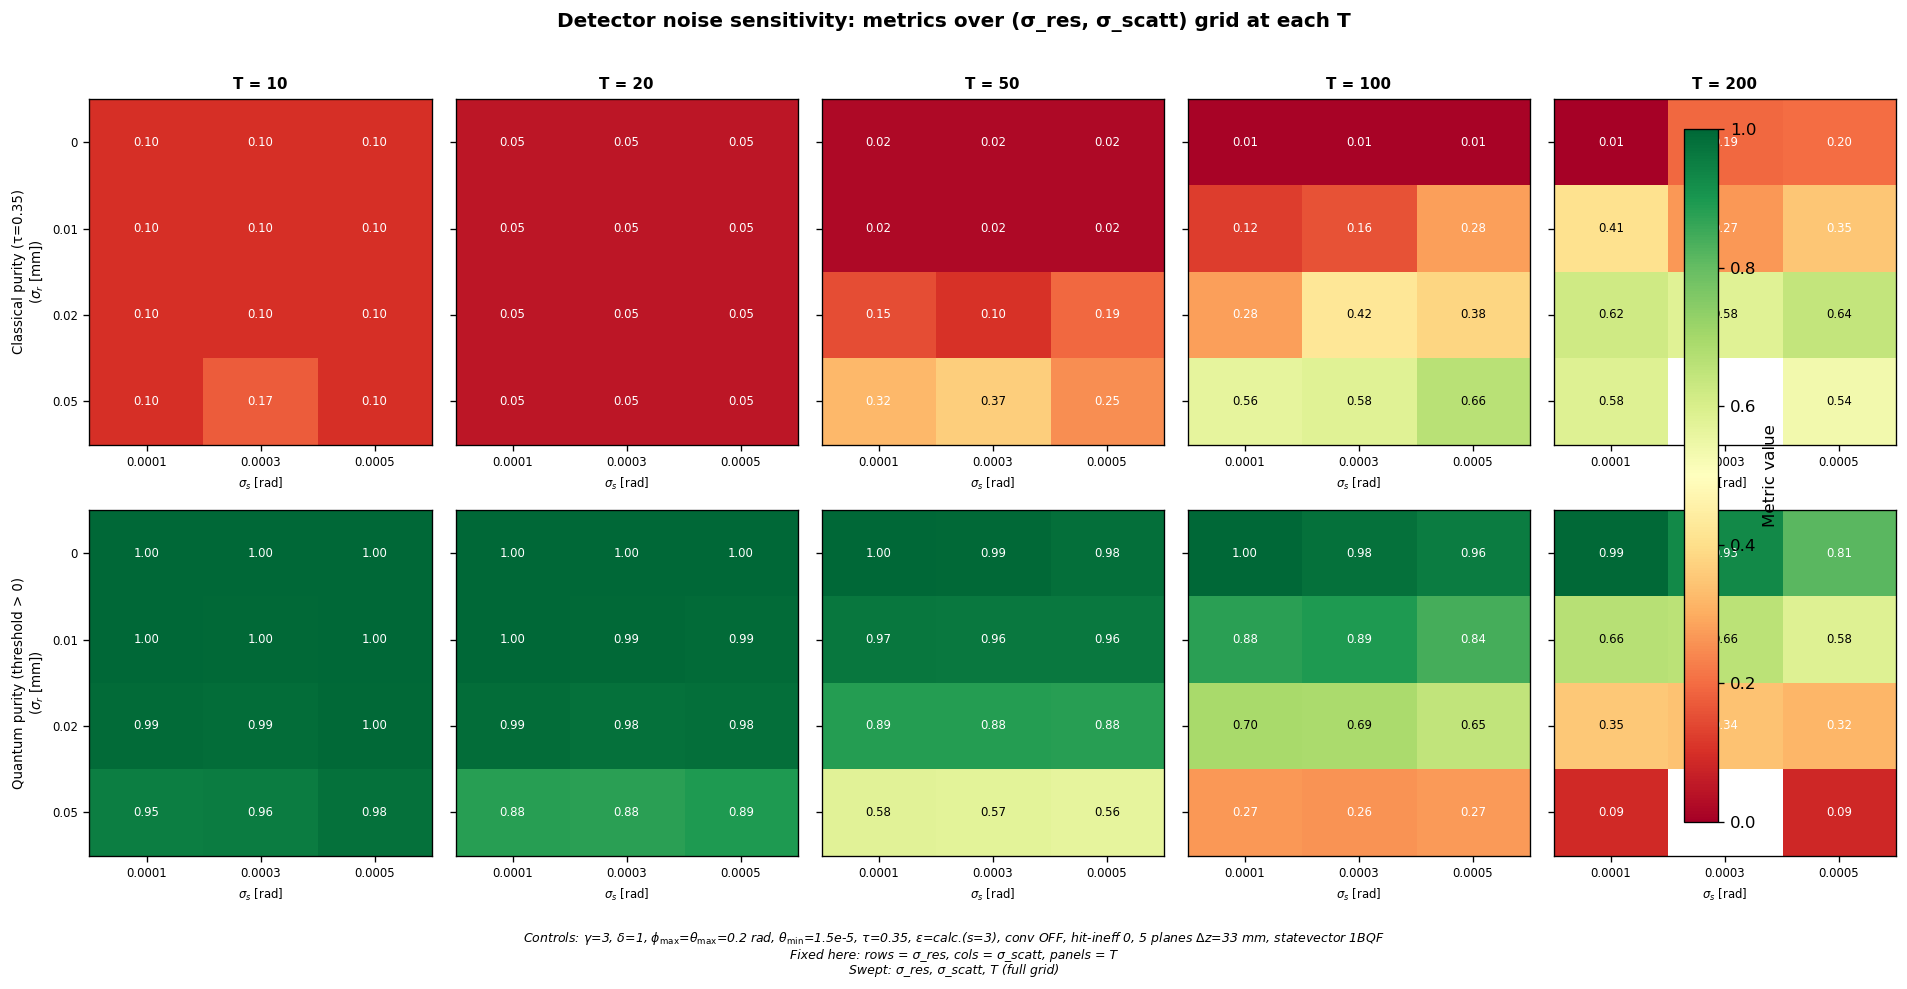

In [27]:
# ── H.3: Heatmap grids — metrics over noise space at every T value ────────────
# Two figures: (cls_eff, q_eff) and (cls_pur, q_pur)
# Each figure: rows = metrics, columns = T values

for (m1, lab1), (m2, lab2), fname in [
    (('cls_eff', 'Classical efficiency'),
     ('q_eff',   'Quantum efficiency (threshold > 0)'),
     'heatmap_efficiency'),
    (('cls_pur', 'Classical purity (τ=0.35)'),
     ('q_pur',   'Quantum purity (threshold > 0)'),
     'heatmap_purity'),
]:
    n_T = len(T_all)
    fig, axes = plt.subplots(2, n_T, figsize=(3.2 * n_T, 7.5), sharey=True)
    if n_T == 1:
        axes = axes.reshape(2, 1)

    for row, (metric, label) in enumerate([(m1, lab1), (m2, lab2)]):
        for ci, T in enumerate(T_all):
            ax = axes[row, ci]
            sub = H_agg[H_agg['n_trk'] == T]
            grid = np.full((n_sr, n_ss), np.nan)
            for ri, sr in enumerate(sr_vals):
                for cj, ss in enumerate(ss_vals):
                    r = sub[(np.isclose(sub.sigma_res, sr)) &
                            (np.isclose(sub.sigma_scatt, ss))]
                    if not r.empty:
                        grid[ri, cj] = float(r[metric].iloc[0])

            im = ax.imshow(grid, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
            ax.set_xticks(range(n_ss))
            ax.set_xticklabels([f'{s:g}' for s in ss_vals], fontsize=7)
            ax.set_yticks(range(n_sr))
            ax.set_yticklabels([f'{s:g}' for s in sr_vals], fontsize=7)
            for ri2 in range(n_sr):
                for cj2 in range(n_ss):
                    v = grid[ri2, cj2]
                    if not np.isnan(v):
                        col = 'white' if v < 0.35 or v > 0.75 else 'black'
                        ax.text(cj2, ri2, f'{v:.2f}', ha='center', va='center',
                                fontsize=7, color=col)
            if row == 0:
                ax.set_title(f'T = {T}', fontsize=9, fontweight='bold')
            if ci == 0:
                ax.set_ylabel(label + '\n' + r'($\sigma_r$ [mm])', fontsize=8)
            ax.set_xlabel(r'$\sigma_s$ [rad]', fontsize=7)

    plt.colorbar(im, ax=axes[:, -1], label='Metric value')
    fig.suptitle('Detector noise sensitivity: metrics over (σ_res, σ_scatt) grid at each T',
                 fontweight='bold', fontsize=12, y=1.01)
    fig.text(0.5, -0.01,
             controls_caption(swept='σ_res, σ_scatt, T (full grid)',
                              extra='rows = σ_res, cols = σ_scatt, panels = T'),
             ha='center', va='top', fontsize=7.5, style='italic')
    plt.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(FDIR_H / f'{fname}.{ext}',
                    dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
    plt.show()

---
## Section I — Score distributions across the full density range

As T grows the false-segment pool expands as T², while the true pool grows only as T.
These plots show directly how the solver score distributions shift at each track density,
for both the best-case (zero noise) and worst-case (maximum noise) detector conditions.

/data/bfys/gscriven/conda/envs/Q_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


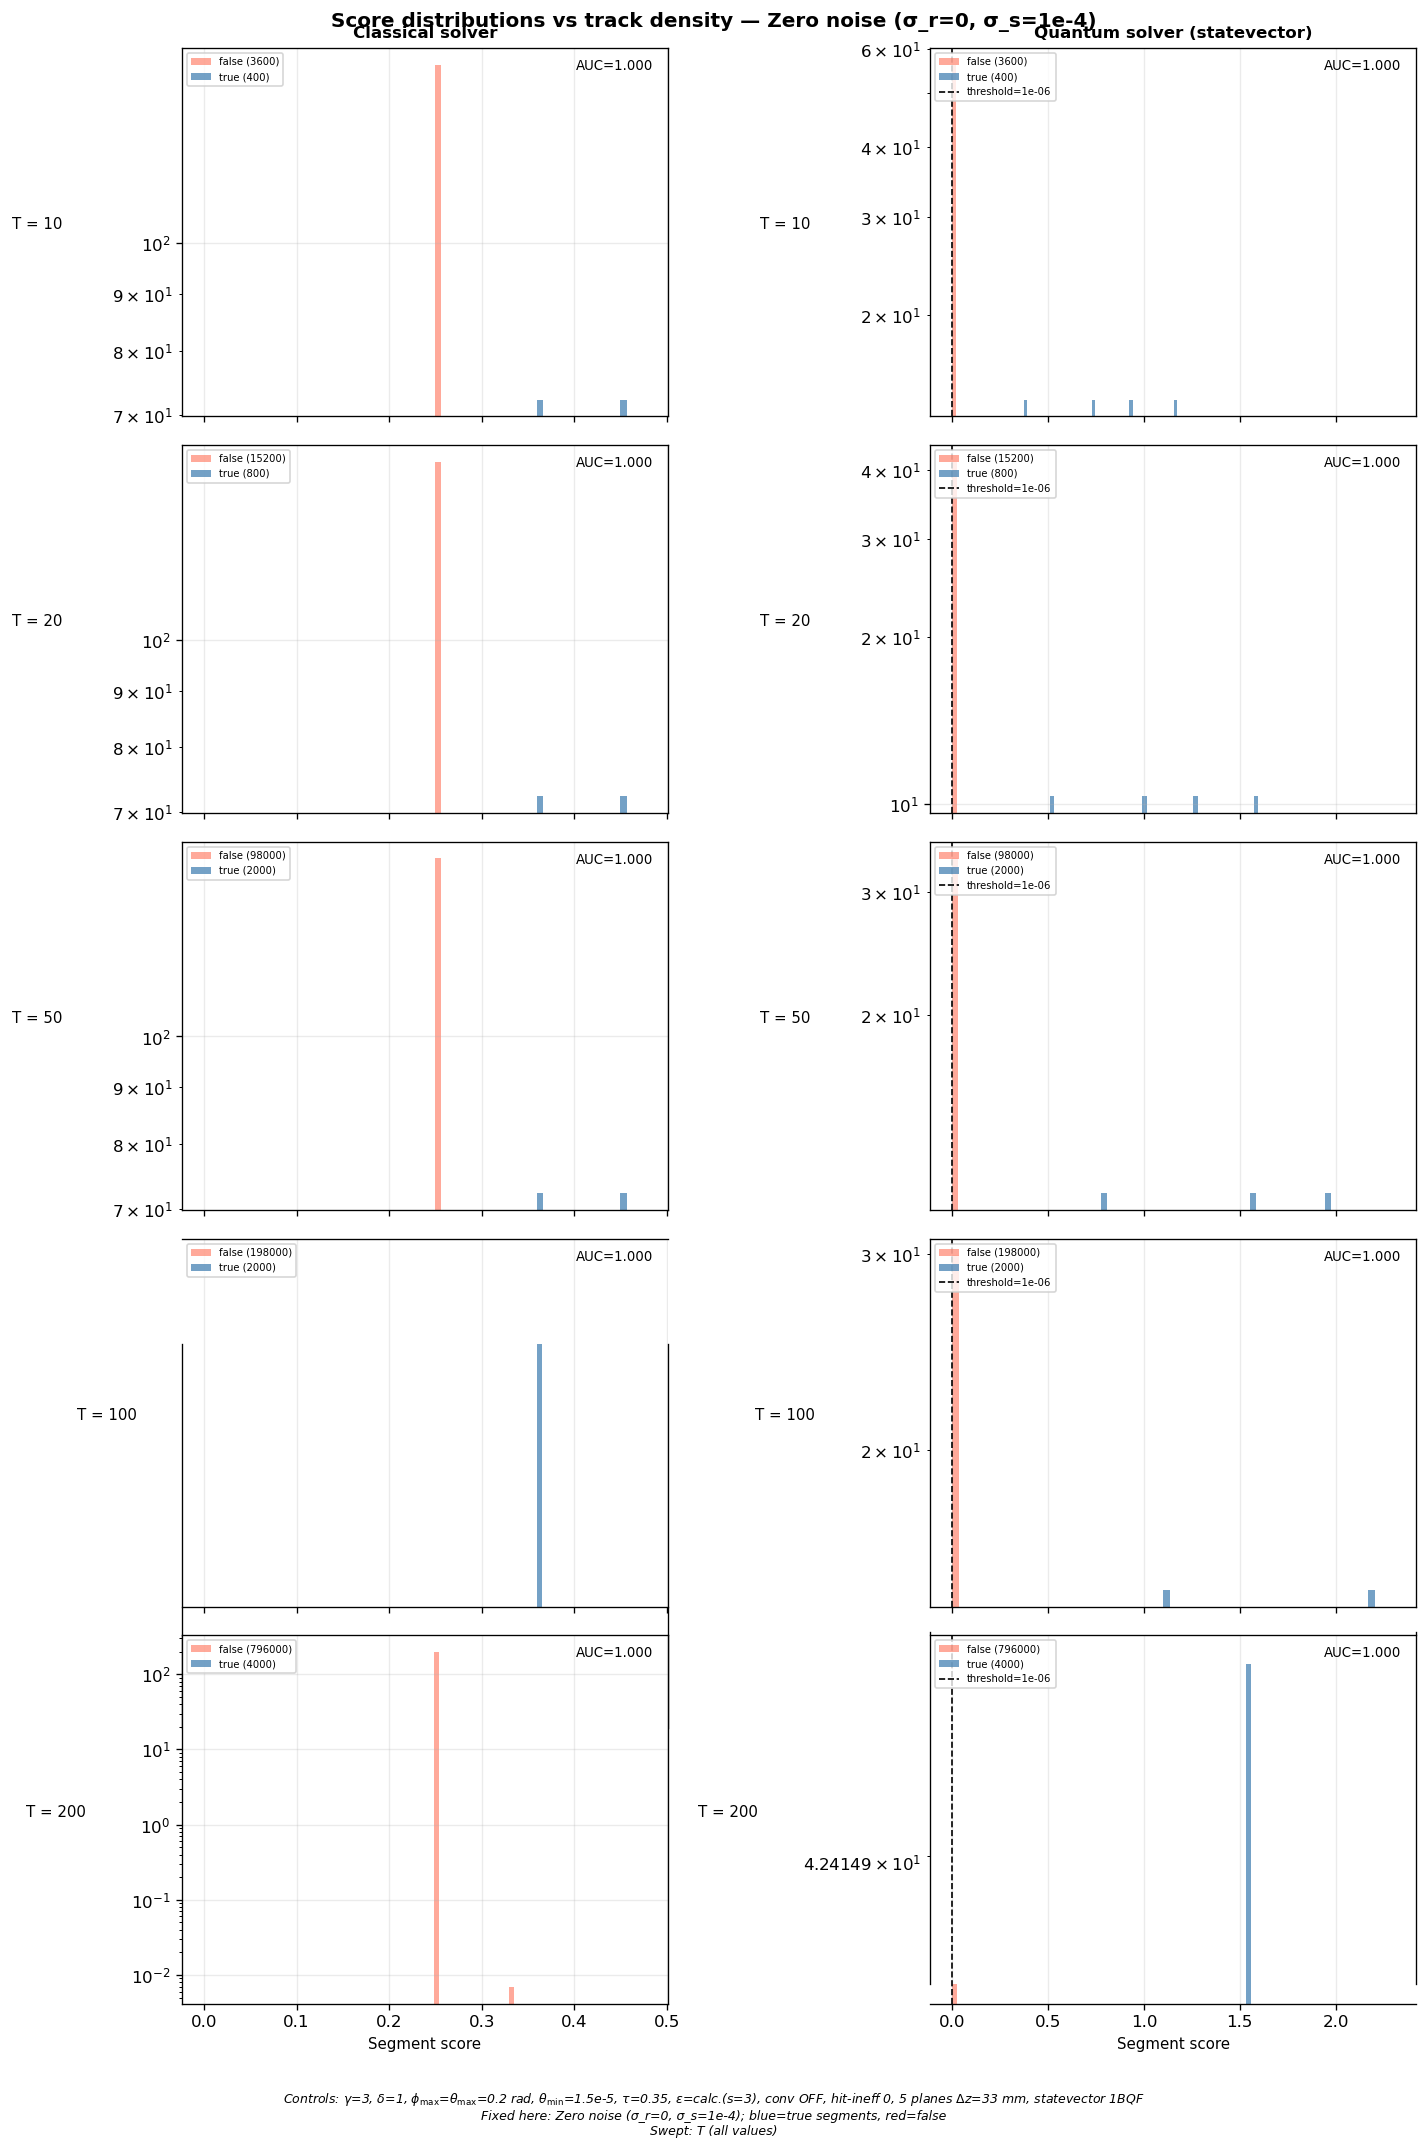

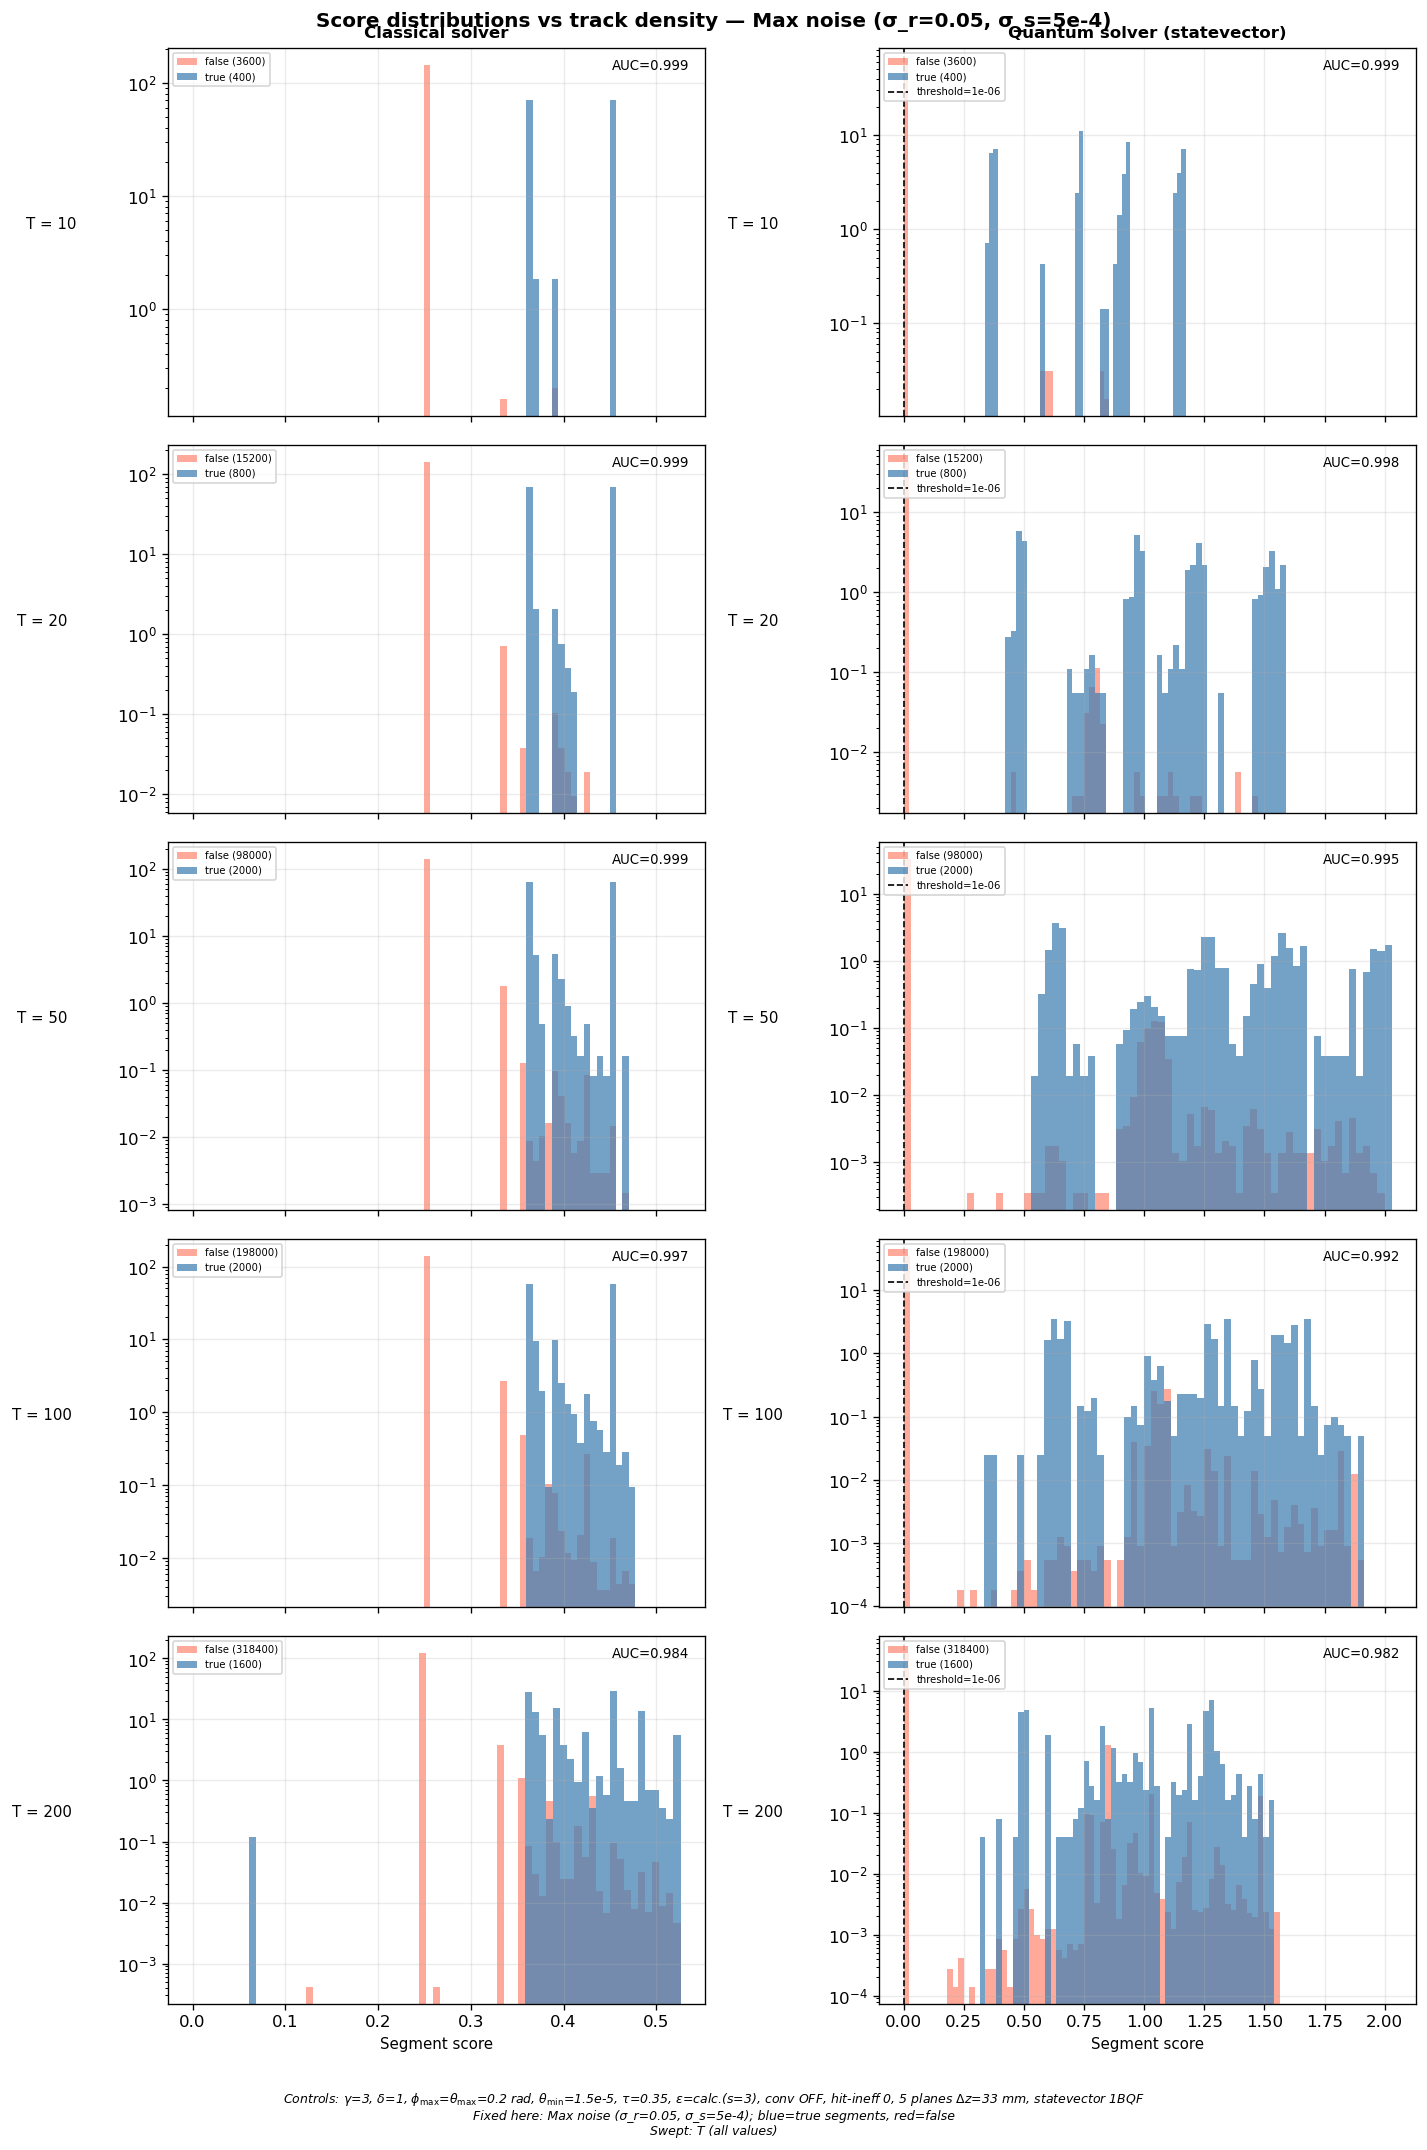

In [28]:
# ── I.1: Score distributions at every T, two noise extremes ──────────────────
FDIR_I = FIGBASE / 'I_score_evolution'
FDIR_I.mkdir(parents=True, exist_ok=True)

NOISE_CASES = [
    ('best',  (sr_vals[0],  ss_vals[0]),  'Zero noise (σ_r=0, σ_s=1e-4)'),
    ('worst', (sr_vals[-1], ss_vals[-1]), 'Max noise (σ_r=0.05, σ_s=5e-4)'),
]

for noise_label, (SR, SS), noise_title in NOISE_CASES:
    pool = {T: {'sc': [], 'sq': [], 'tr': []}
            for T in T_all}
    for r in sens_records:
        T = int(r['n_trk'])
        if T not in pool: continue
        if not (np.isclose(r['sigma_res'], SR) and
                np.isclose(r['sigma_scatt'], SS)): continue
        sc = r.get('sol_C'); sq = r.get('sol_Q'); tr = r.get('truth')
        if sc is None or tr is None: continue
        pool[T]['sc'].extend(np.asarray(sc, float).tolist())
        pool[T]['tr'].extend(np.asarray(tr, bool).tolist())
        if sq is not None:
            pool[T]['sq'].extend(np.asarray(sq, float).tolist())

    n_T = len(T_all)
    fig, axes = plt.subplots(n_T, 2, figsize=(12, 3.5 * n_T), sharex='col')
    if n_T == 1:
        axes = axes.reshape(1, 2)

    for ri, T in enumerate(T_all):
        d = pool[T]
        sc = np.array(d['sc']); tr = np.array(d['tr'], bool)
        sq = np.array(d['sq']) if d['sq'] else None

        for ci, (scores, title) in enumerate([
                (sc, 'Classical solver'),
                (sq, 'Quantum solver (statevector)')]):
            ax = axes[ri, ci]
            if scores is None or len(scores) == 0:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes)
                continue

            tr_use = tr if ci == 0 else np.array(d['tr'], bool)[:len(scores)]

            # Use log-scale y; plot false first (grey), true on top (coloured)
            x_max = np.percentile(scores, 99.5)
            bins = np.linspace(0, x_max * 1.05, 70)
            ax.hist(scores[~tr_use], bins=bins, color='tomato', alpha=0.55,
                    label=f'false ({(~tr_use).sum()})', density=True, log=True)
            ax.hist(scores[tr_use],  bins=bins, color='steelblue', alpha=0.75,
                    label=f'true ({tr_use.sum()})',  density=True, log=True)

            if ci == 1:
                ax.axvline(Q_THRESH, color='k', ls='--', lw=1,
                           label=f'threshold={Q_THRESH:.0e}')

            auc = _auc(scores, tr_use)
            ax.text(0.97, 0.97, f'AUC={auc:.3f}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8)
            ax.set_ylabel(f'T = {T}', fontsize=9, rotation=0, labelpad=45)
            if ri == 0:
                ax.set_title(title, fontsize=10, fontweight='bold')
            if ri == n_T - 1:
                ax.set_xlabel('Segment score', fontsize=9)
            ax.legend(fontsize=6, loc='upper left')
            ax.grid(alpha=0.25)

    fig.suptitle(f'Score distributions vs track density — {noise_title}',
                 fontweight='bold', fontsize=12)
    fig.text(0.5, -0.01,
             controls_caption(swept='T (all values)',
                              extra=f'{noise_title}; blue=true segments, red=false'),
             ha='center', va='top', fontsize=7.5, style='italic')
    plt.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(FDIR_I / f'score_evolution_{noise_label}.{ext}',
                    dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
    plt.show()

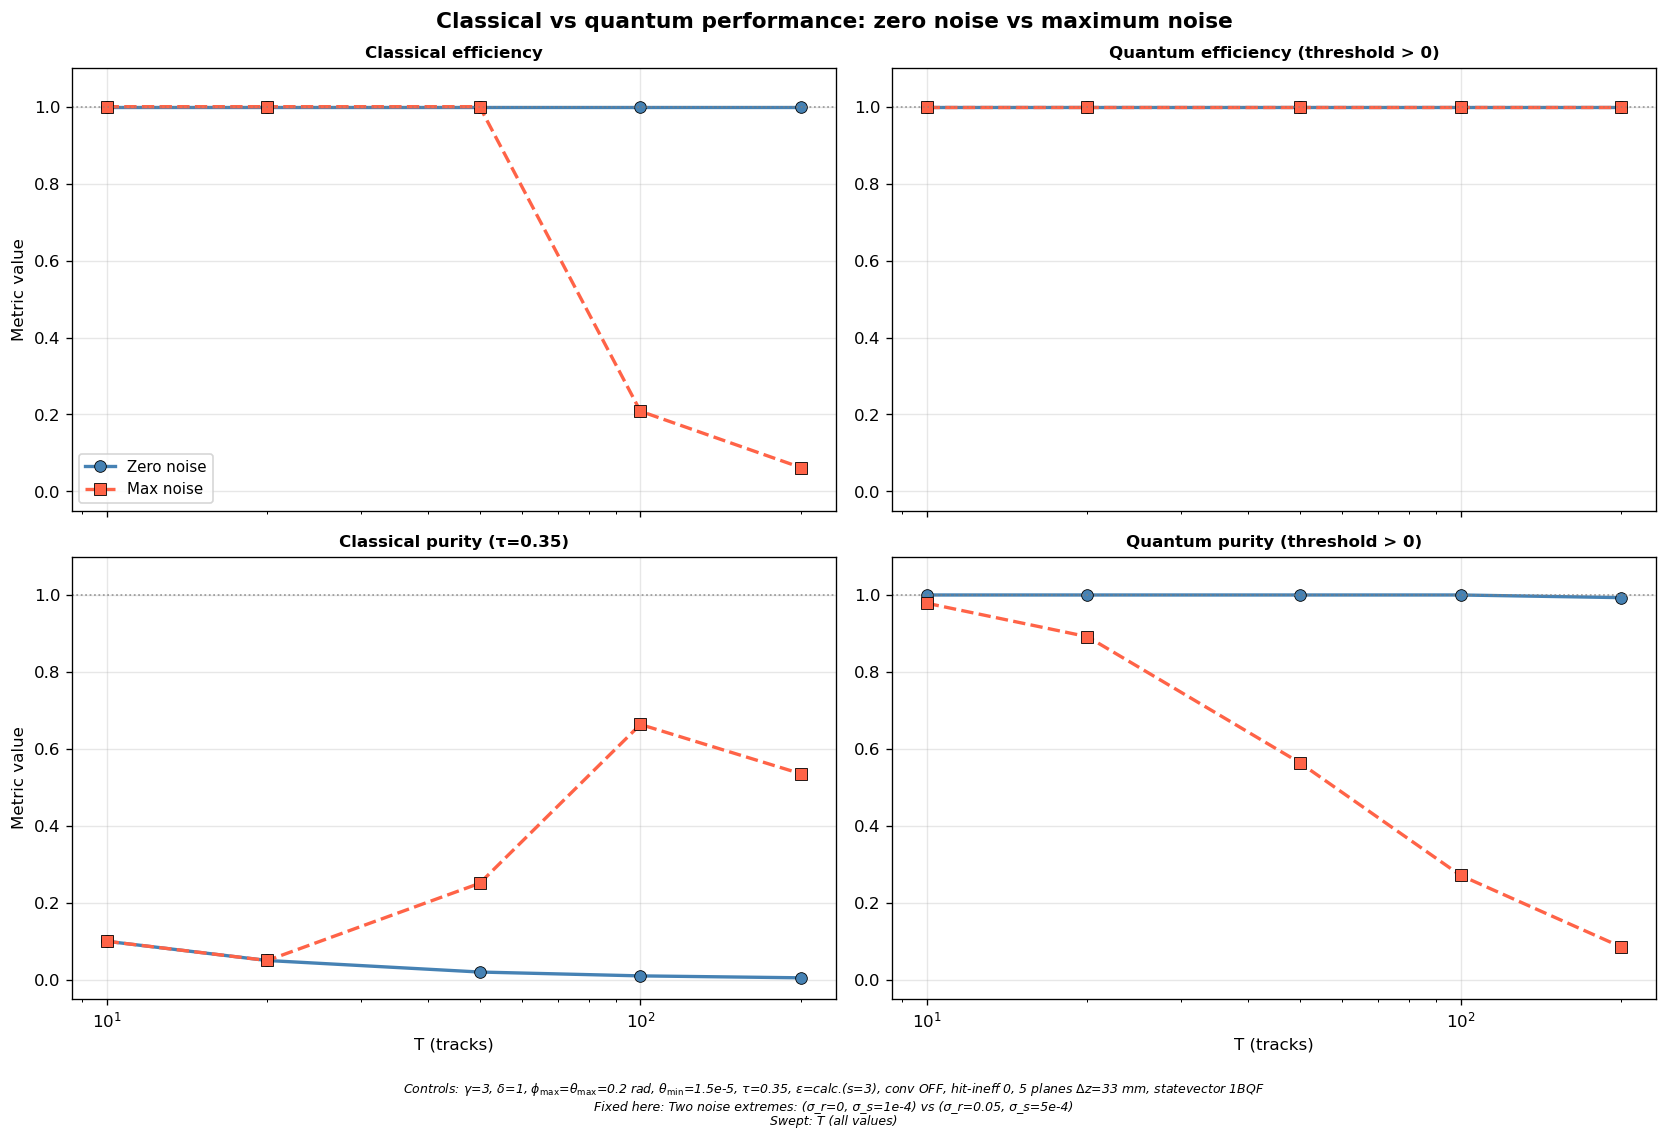

In [29]:
# ── I.2: Classical vs quantum efficiency and purity — direct comparison ───────
# One panel per metric, all T on x-axis, best and worst noise conditions overlaid
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)

COMPARE_CASES = [
    ((sr_vals[0],  ss_vals[0]),  'Zero noise', 'steelblue', 'o', '-'),
    ((sr_vals[-1], ss_vals[-1]), 'Max noise',  'tomato',    's', '--'),
]

for (SR, SS), label, base_color, marker, ls in COMPARE_CASES:
    for (ax, metric, title) in [
        (axes[0, 0], 'cls_eff', 'Classical efficiency'),
        (axes[0, 1], 'q_eff',   'Quantum efficiency (threshold > 0)'),
        (axes[1, 0], 'cls_pur', 'Classical purity (τ=0.35)'),
        (axes[1, 1], 'q_pur',   'Quantum purity (threshold > 0)'),
    ]:
        sub = H_agg[(np.isclose(H_agg.sigma_res, SR)) &
                    (np.isclose(H_agg.sigma_scatt, SS))].sort_values('n_trk')
        if sub.empty:
            continue
        ax.plot(sub['n_trk'], sub[metric], color=base_color, ls=ls,
                lw=2, marker=marker, ms=7, mec='black', mew=0.5,
                label=label)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_ylim(-0.05, 1.1)
        ax.axhline(1.0, color='grey', ls=':', lw=1, alpha=0.5)
        ax.grid(alpha=0.3)
        ax.set_xscale('log')

for ax in axes[1]:
    ax.set_xlabel('T (tracks)', fontsize=10)
for ax in axes[:, 0]:
    ax.set_ylabel('Metric value', fontsize=10)

axes[0, 0].legend(fontsize=9)
fig.suptitle('Classical vs quantum performance: zero noise vs maximum noise',
             fontweight='bold', fontsize=13)
fig.text(0.5, -0.01,
         controls_caption(
             swept='T (all values)',
             extra='Two noise extremes: (σ_r=0, σ_s=1e-4) vs (σ_r=0.05, σ_s=5e-4)'),
         ha='center', va='top', fontsize=7.5, style='italic')
plt.tight_layout()
for ext in ('pdf', 'png'):
    fig.savefig(FDIR_I / f'classical_vs_quantum_noise_comparison.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight', facecolor='white')
plt.show()